QUESTION 2: BATTERY-AWARE ROBOT NAVIGATION

(a) MDP DEFINITION
Battery-Aware Robot Navigation MDP
Grid Size: 8x8
Max Battery: 10
Obstacles: [(1, 1), (2, 6), (3, 3), (5, 2), (6, 5)]
Charging Stations: [(0, 3), (4, 4), (7, 1)]
Goal: (7, 7)
Start: (0, 0)
Number of states: 649 + terminal
Number of actions: 5

    MDP Definition:
    State Space: S = {(x, y, b) | x ∈ [0,7], y ∈ [0,7], (x,y) ∉ obstacles, b ∈ [0,10]}
    Total states: 649 (+ terminal)
    
    Action Space: A = {Up, Down, Left, Right, Recharge}
    
    Transition Model (Deterministic):
    - Move actions (Up/Down/Left/Right):
        * Moves to adjacent cell, battery decreases by 1
        * If target cell is obstacle or boundary: stay in place, battery still decreases
        * If battery reaches 0 away from charging station → TERMINAL (failure)
        * If target cell is goal → TERMINAL (success)
    - Recharge:
        * Only effective at charging stations when b < B_max
        * Restores battery to maximum (B = 10)
   

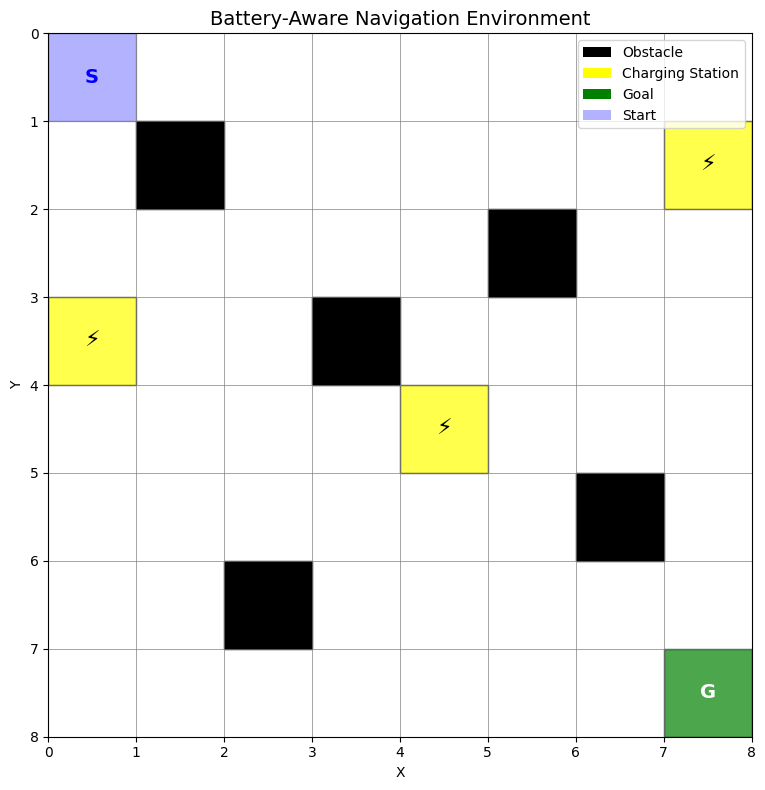

Saved: battery_grid.png

(b) VALUE ITERATION SOLUTION (γ=0.99)

--- Value Iteration (γ=0.99) ---
Converged in 1376 iterations
Runtime: 37.8802 seconds
Peak memory: 110.06 KB

Policy (VI, γ=0.99) (battery=10):
--------------------------------------------------
 0 |  D | R | D | D | D | D | D | D |
 1 |  D | X | D | D | D | R | D | D |
 2 |  D | D | D | R | D | X | D | D |
 3 |  D | D | D | X | D | D | D | D |
 4 |  D | D | D | D | D | D | R | D |
 5 |  D | D | R | D | D | D | X | D |
 6 |  D | D | X | D | D | D | D | D |
 7 |  R | R | R | R | R | R | R | G |
--------------------------------------------------

Policy (VI, γ=0.99) (battery=5):
--------------------------------------------------
 0 |  D | L | D | D | D | D | D | D |
 1 |  D | X | D | D | D | R | R | C |
 2 |  D | D | D | R | D | X | U | D |
 3 |  D | D | D | X | D | D | D | D |
 4 |  R | R | R | R | C | D | R | D |
 5 |  U | U | U | U | D | D | X | D |
 6 |  U | U | X | D | D | D | D | D |
 7 |  U | U | R | R | R | R | R | 

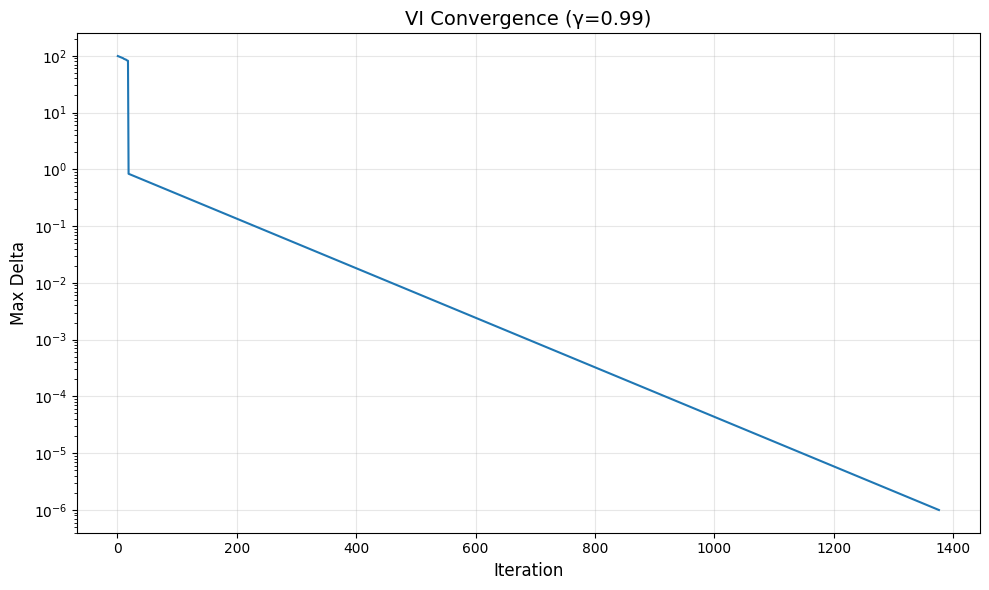

Saved: battery_conv_vi_099.png


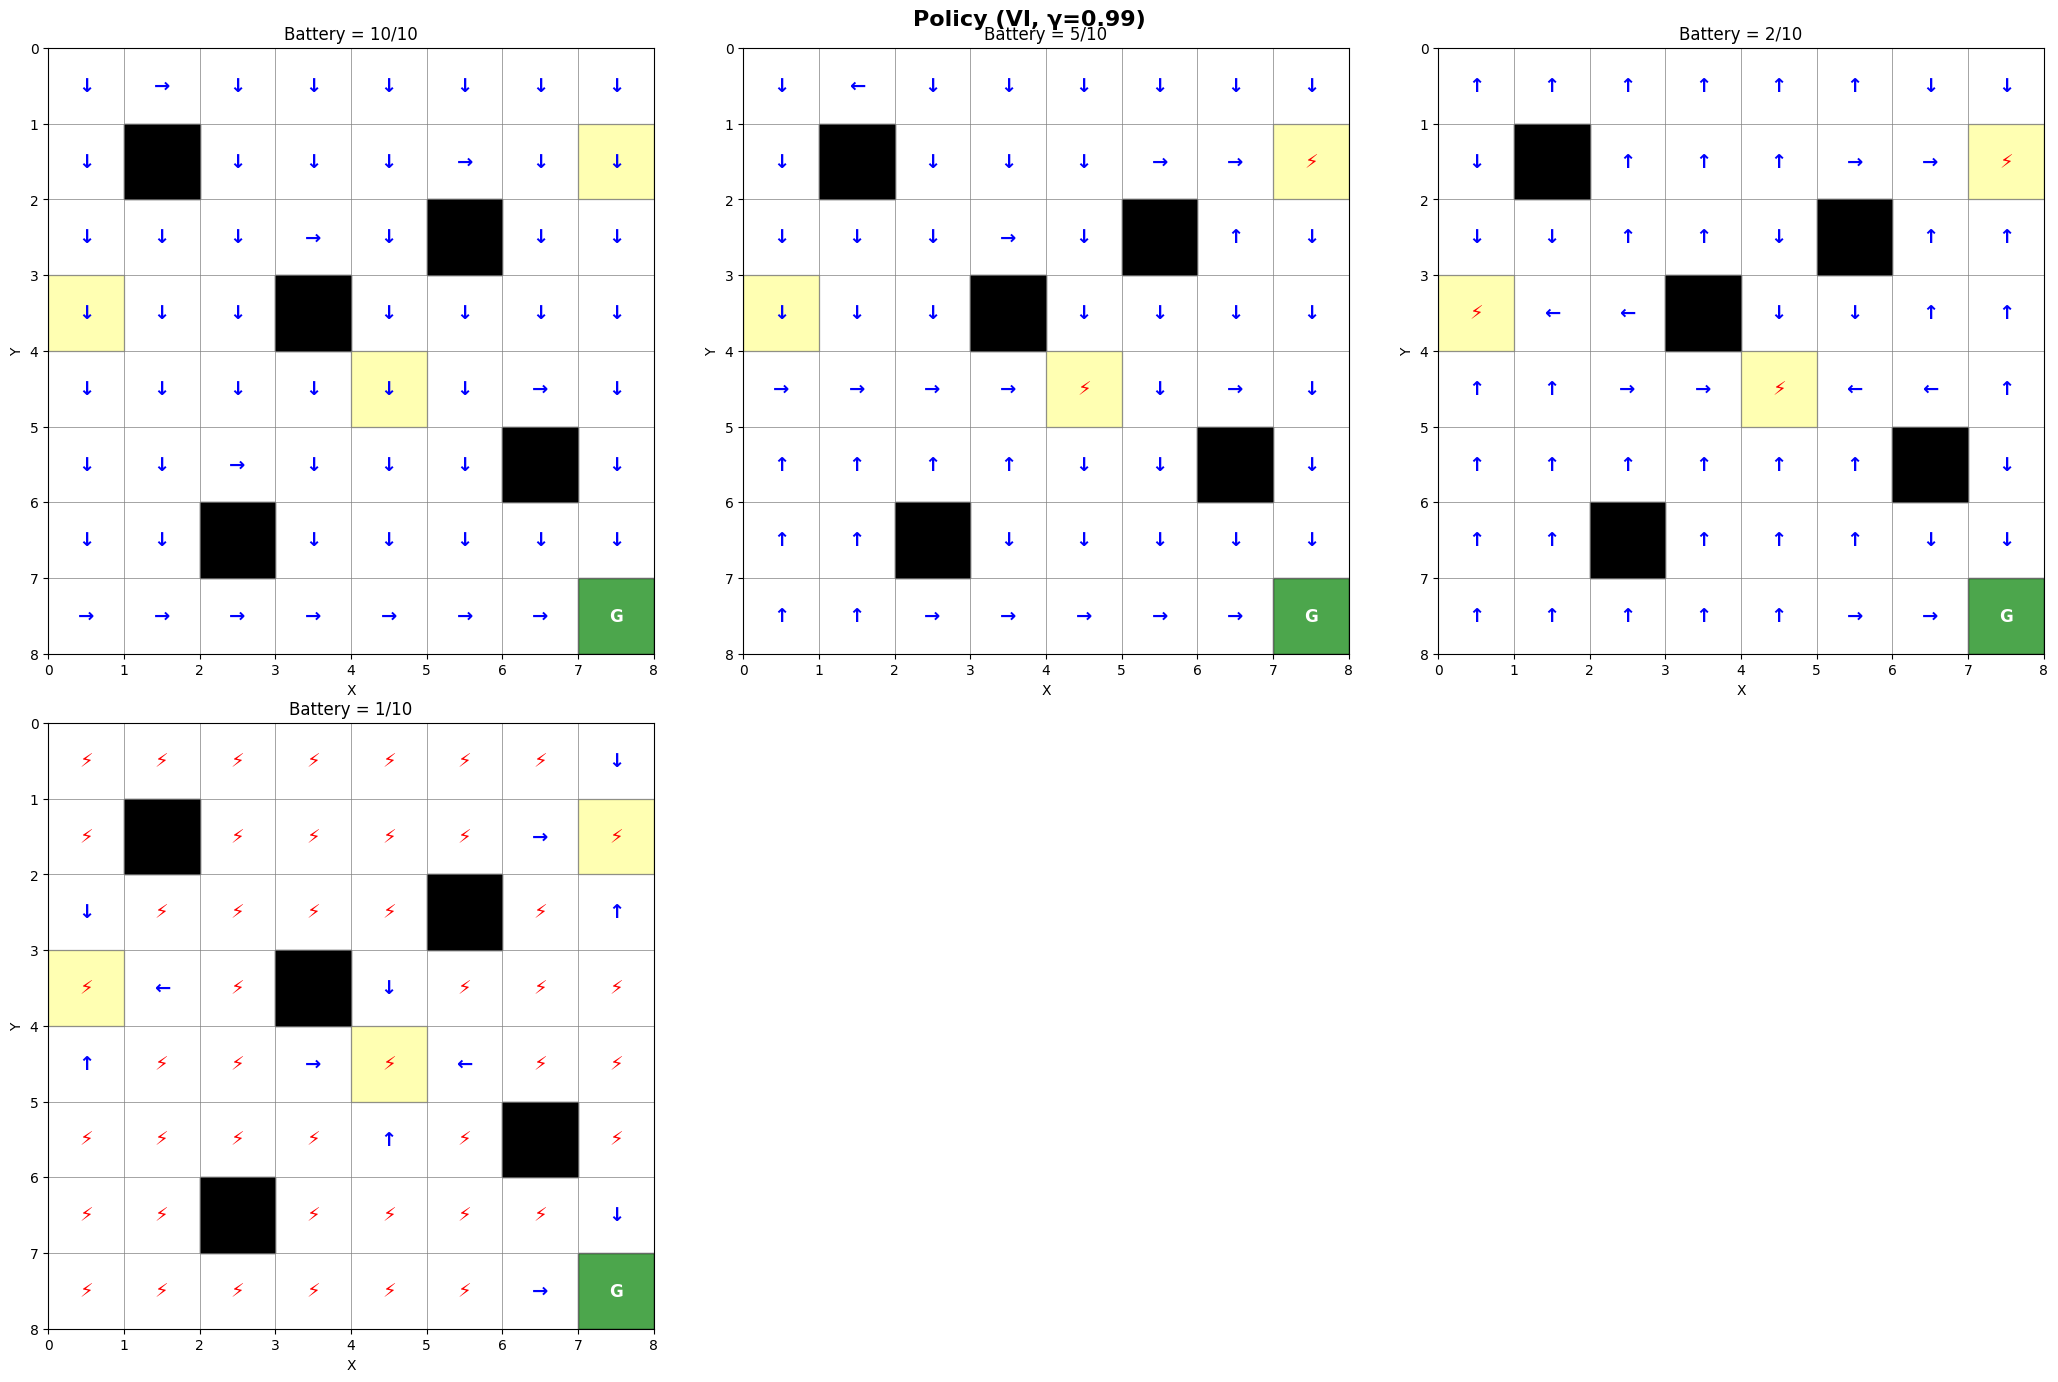

Saved: battery_policy_vi_099.png


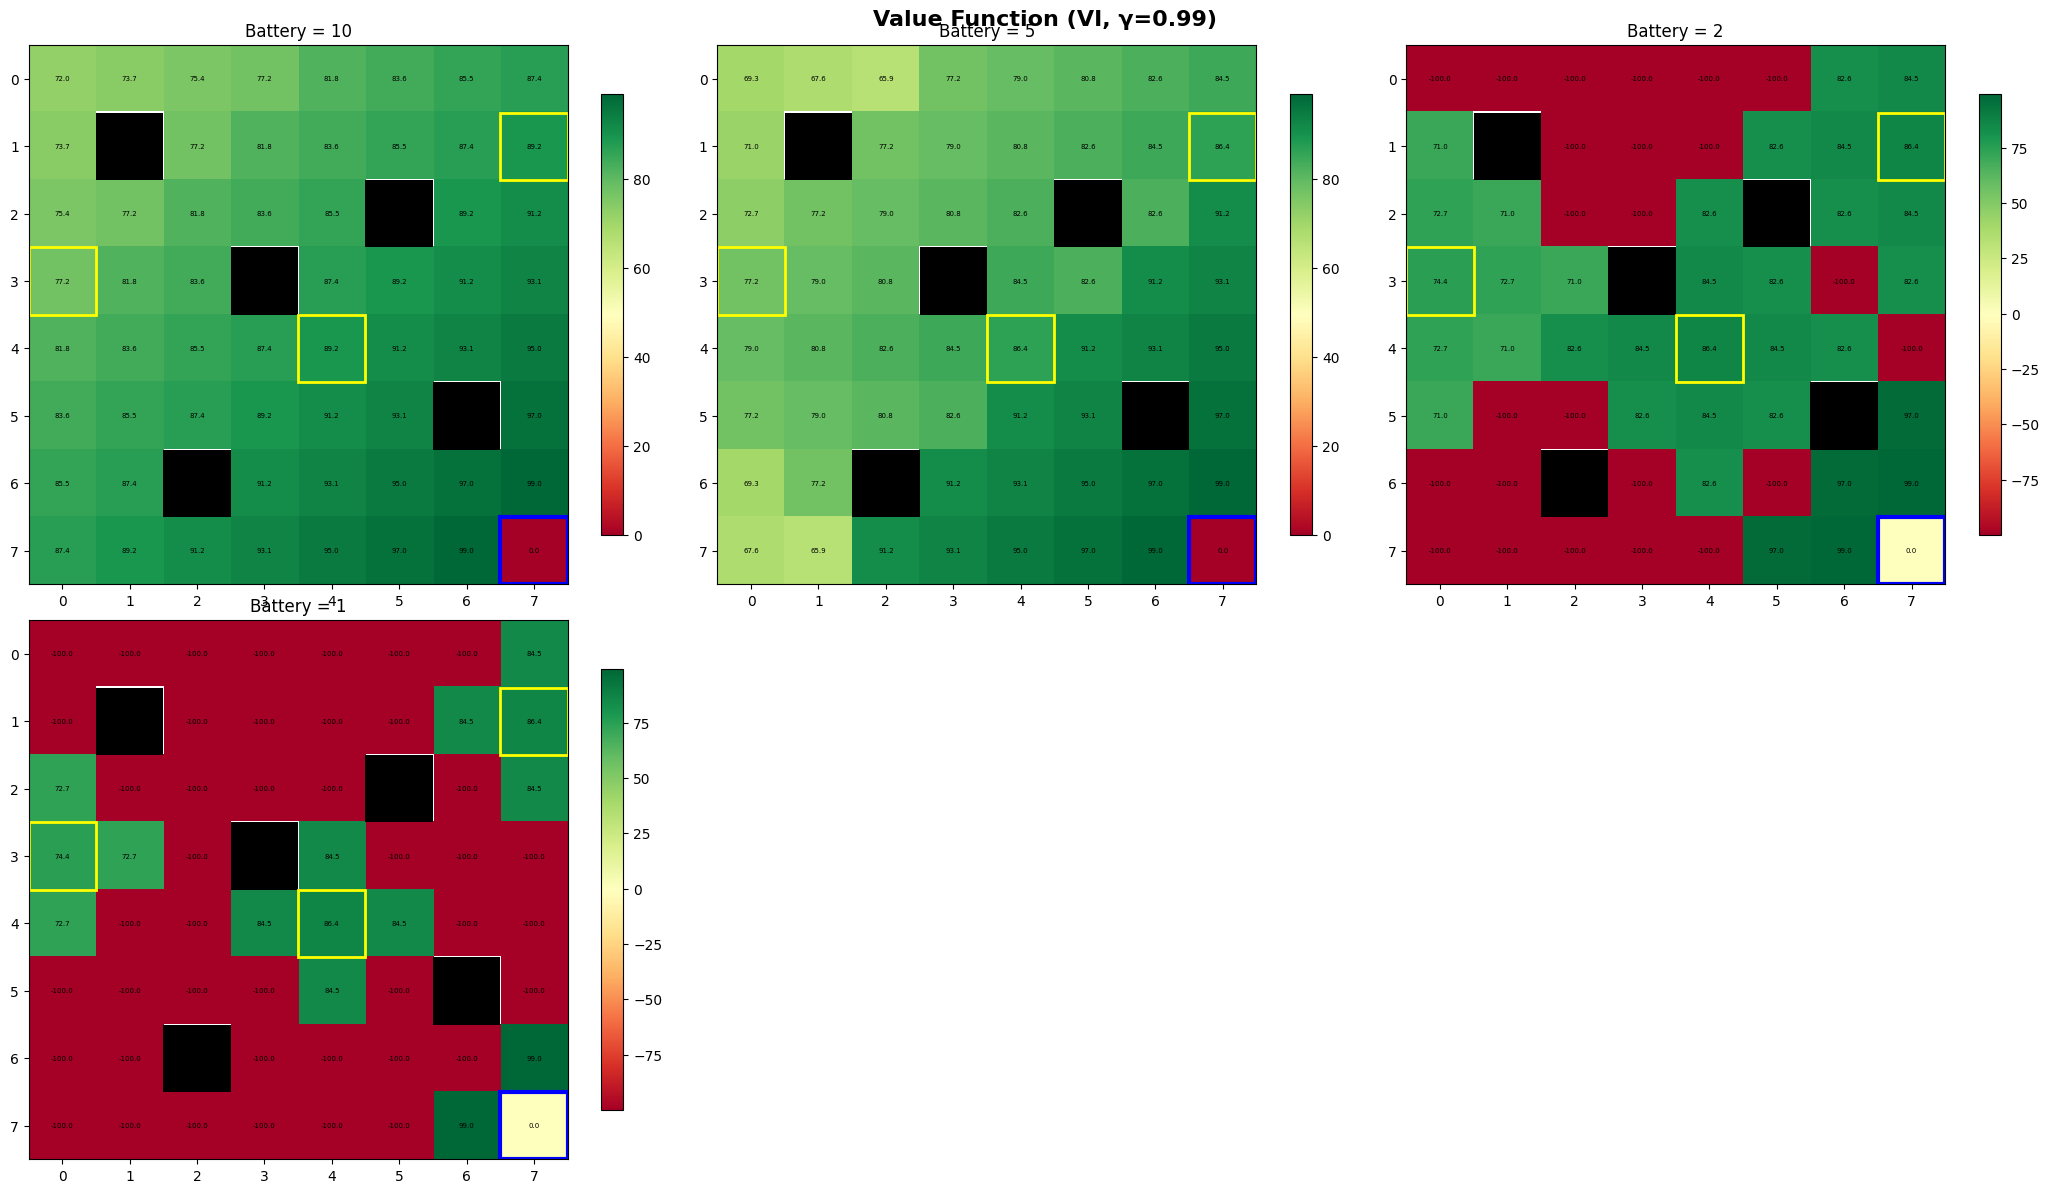

Saved: battery_value_vi_099.png

Trajectory from start with full battery:
  Steps: 15
  Total reward: 84.00
  Step 1: (0, 0, 10) --Down--> (0, 1, 9) (R=-1)
  Step 2: (0, 1, 9) --Down--> (0, 2, 8) (R=-1)
  Step 3: (0, 2, 8) --Down--> (0, 3, 7) (R=-1)
  Step 4: (0, 3, 7) --Down--> (0, 4, 6) (R=-1)
  Step 5: (0, 4, 6) --Right--> (1, 4, 5) (R=-1)
  Step 6: (1, 4, 5) --Right--> (2, 4, 4) (R=-1)
  Step 7: (2, 4, 4) --Right--> (3, 4, 3) (R=-1)
  Step 8: (3, 4, 3) --Right--> (4, 4, 2) (R=-1)
  Step 9: (4, 4, 2) --Recharge--> (4, 4, 10) (R=-2)
  Step 10: (4, 4, 10) --Down--> (4, 5, 9) (R=-1)
  Step 11: (4, 5, 9) --Down--> (4, 6, 8) (R=-1)
  Step 12: (4, 6, 8) --Down--> (4, 7, 7) (R=-1)
  Step 13: (4, 7, 7) --Right--> (5, 7, 6) (R=-1)
  Step 14: (5, 7, 6) --Right--> (6, 7, 5) (R=-1)
  Step 15: (6, 7, 5) --Right--> TERMINAL (R=99)


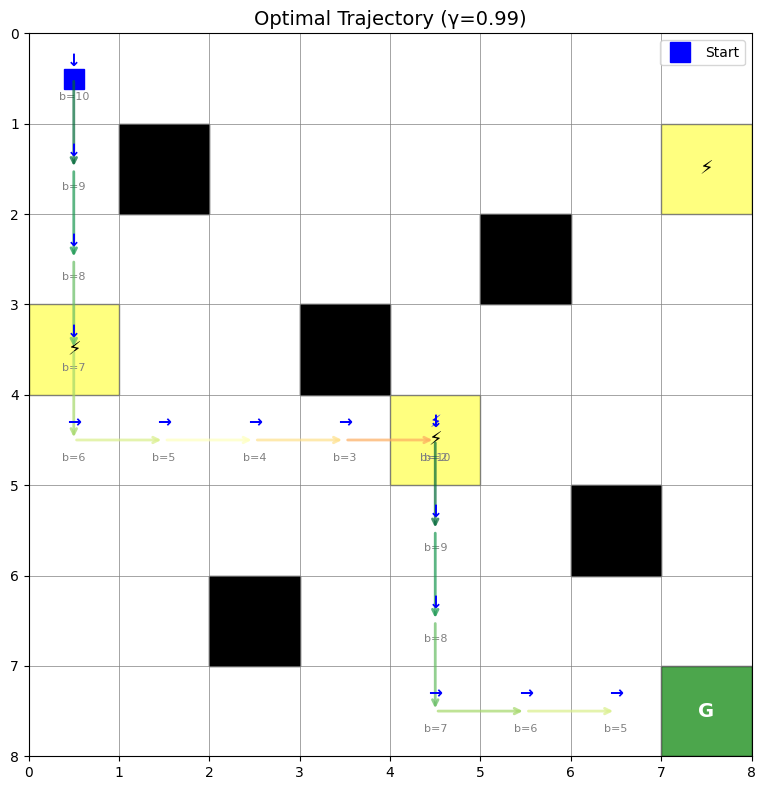

Saved: battery_traj_099.png

(c) COMPARISON ACROSS DISCOUNT FACTORS

======================================== γ = 0.99 ========================================

--- Value Iteration (γ=0.99) ---
Converged in 1376 iterations
Runtime: 29.7422 seconds
Peak memory: 110.24 KB

--- Policy Iteration (γ=0.99) ---
Converged in 12 iterations
Runtime: 78.2794 seconds
Peak memory: 82.41 KB


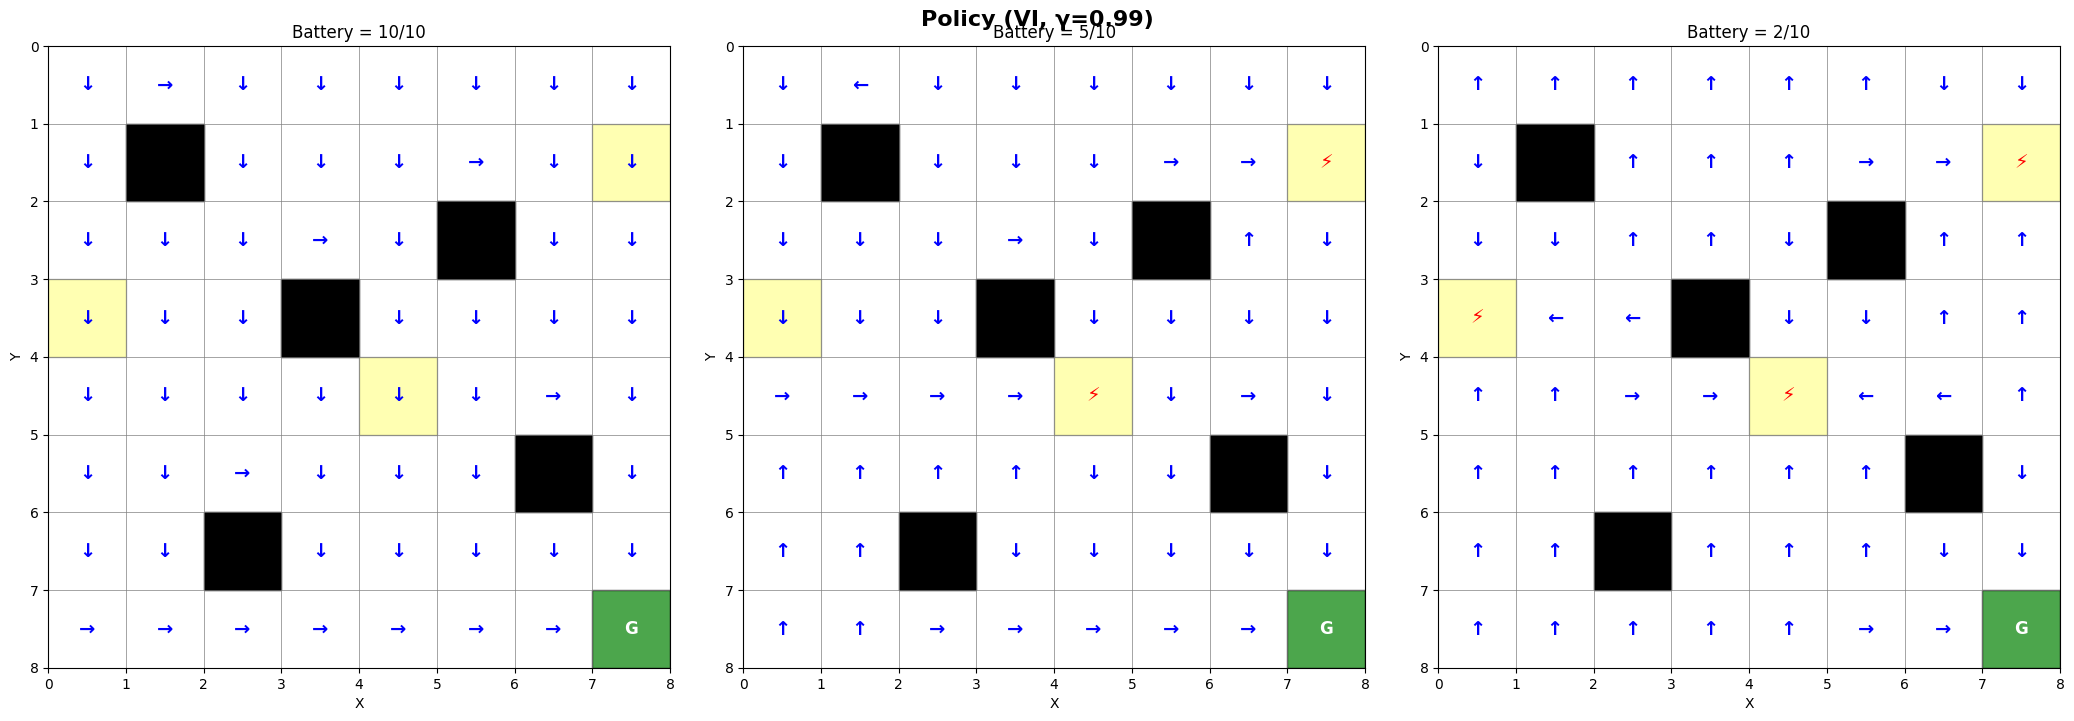

Saved: battery_policy_vi_099.png


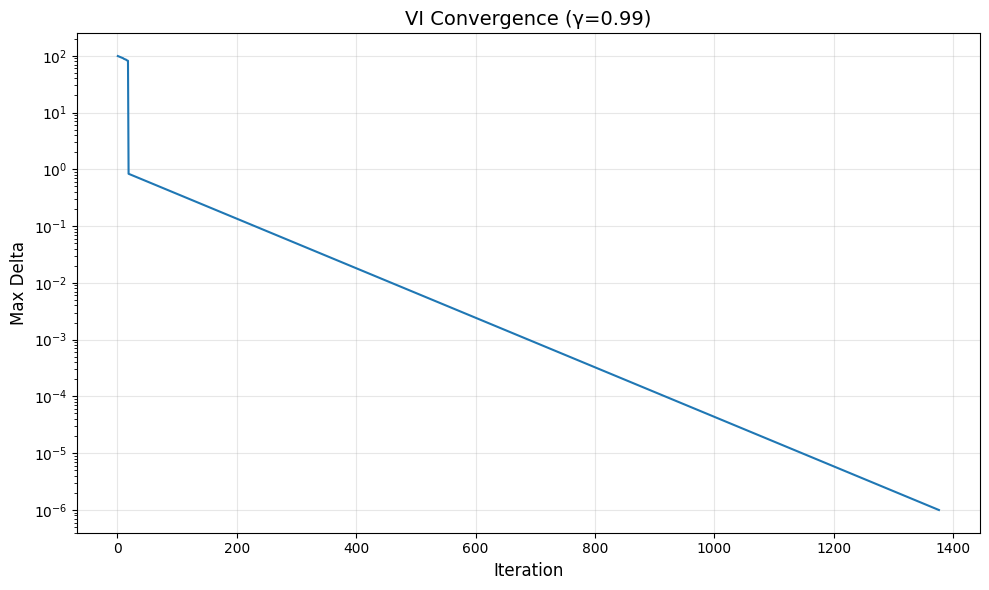

Saved: battery_conv_vi_099.png
  Trajectory length: 15, Total reward: 84.00

======================================== γ = 0.9 ========================================

--- Value Iteration (γ=0.9) ---
Converged in 133 iterations
Runtime: 3.8726 seconds
Peak memory: 71.36 KB

--- Policy Iteration (γ=0.9) ---
Converged in 12 iterations
Runtime: 7.2029 seconds
Peak memory: 82.91 KB


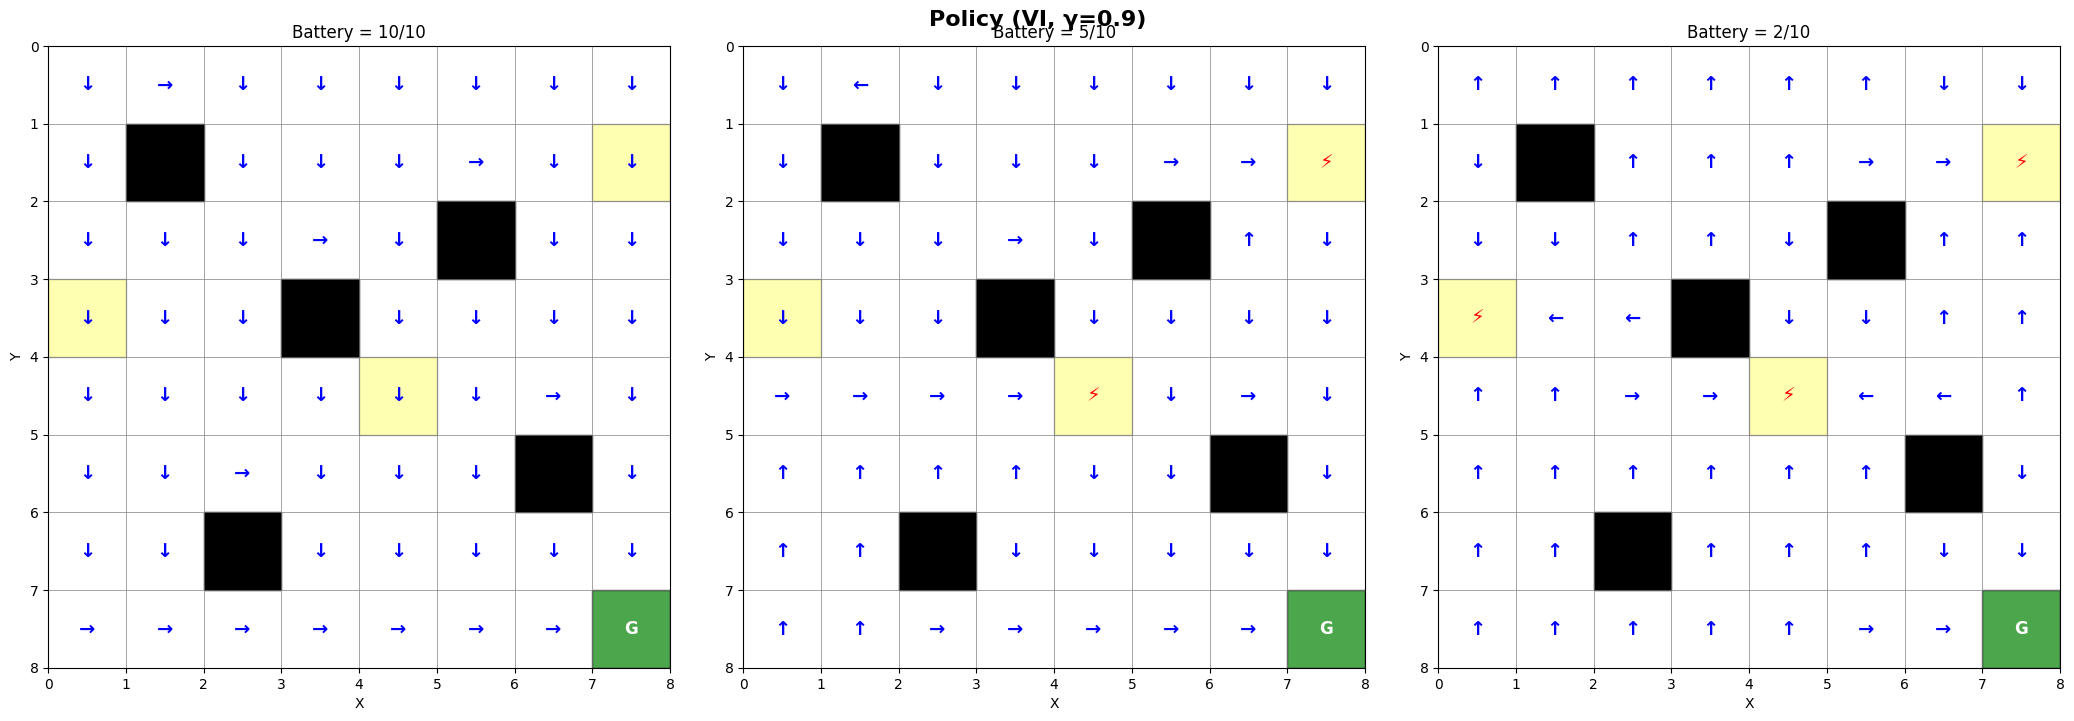

Saved: battery_policy_vi_09.png


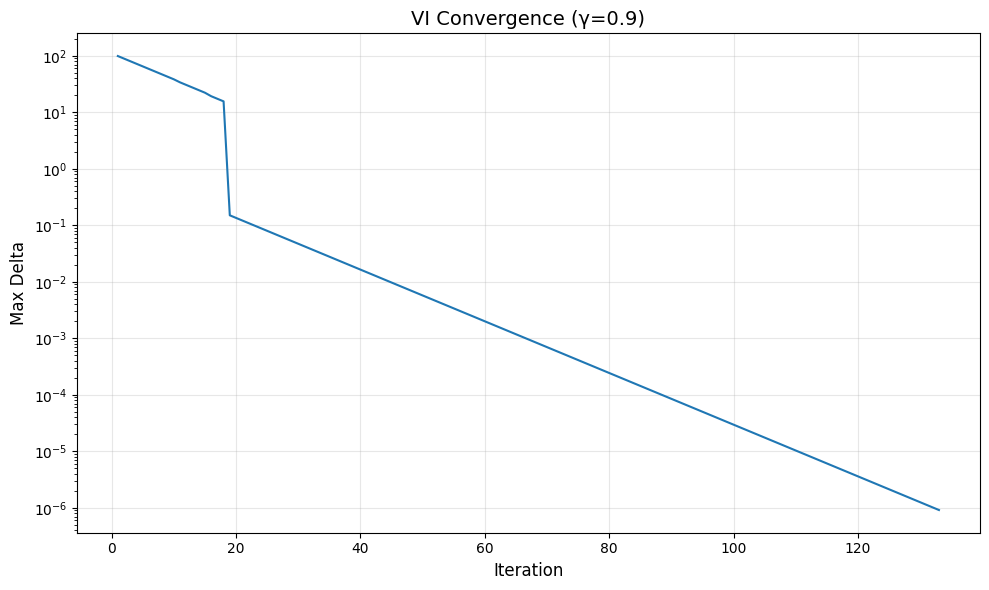

Saved: battery_conv_vi_09.png
  Trajectory length: 15, Total reward: 84.00

======================================== γ = 0.7 ========================================

--- Value Iteration (γ=0.7) ---
Converged in 40 iterations
Runtime: 1.2500 seconds
Peak memory: 68.27 KB

--- Policy Iteration (γ=0.7) ---
Converged in 14 iterations
Runtime: 2.9044 seconds
Peak memory: 82.95 KB


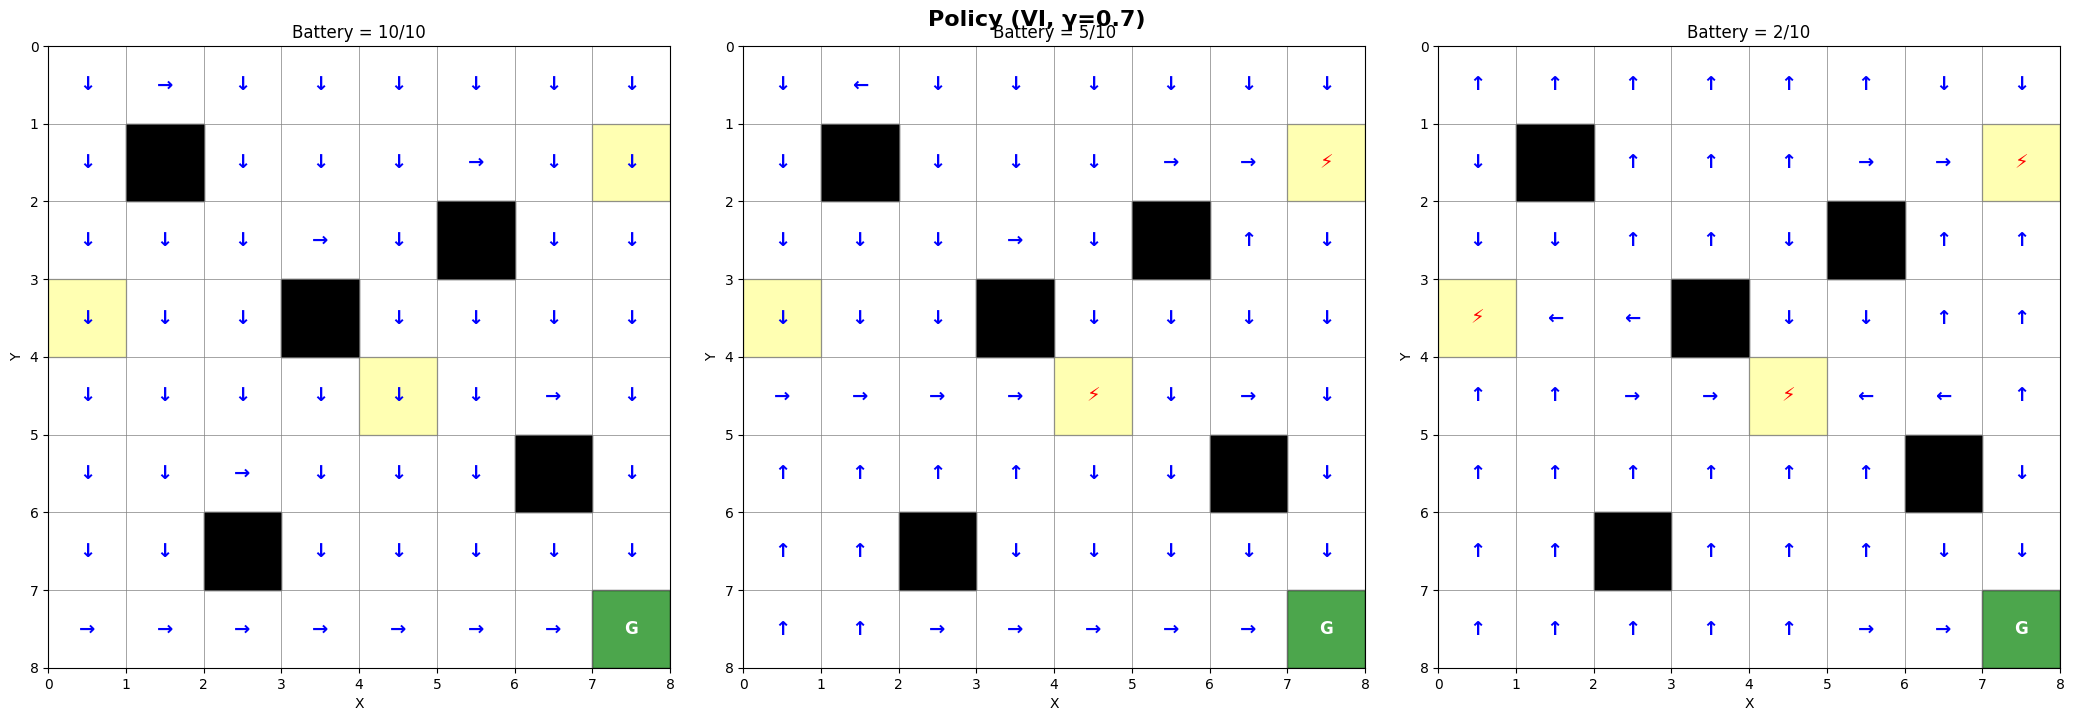

Saved: battery_policy_vi_07.png


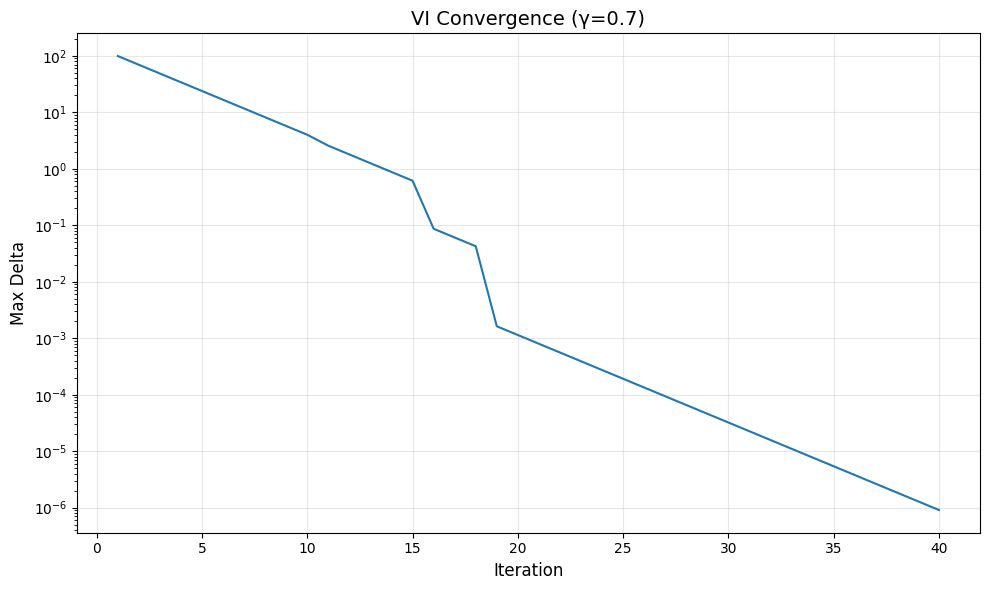

Saved: battery_conv_vi_07.png
  Trajectory length: 15, Total reward: 84.00

(d) POLICY COMPARISON ACROSS DISCOUNT FACTORS

    ┌─────────────────────────┬────────────┬────────────┬────────────┐
    │ Metric                  │  γ = 0.99  │  γ = 0.9   │  γ = 0.7   │
    ├─────────────────────────┼────────────┼────────────┼────────────┤
    │ VI Iterations           │       1376 │        133 │         40 │
    │ VI Runtime (s)          │    29.7422 │     3.8726 │     1.2500 │
    │ VI Memory (KB)          │     110.24 │      71.36 │      68.27 │
    │ PI Iterations           │         12 │         12 │         14 │
    │ PI Runtime (s)          │    78.2794 │     7.2029 │     2.9044 │
    │ PI Memory (KB)          │      82.41 │      82.91 │      82.95 │
    └─────────────────────────┴────────────┴────────────┴────────────┘
    
  Policy match γ=0.99 vs γ=0.9: 649/649 states
  Policy match γ=0.9 vs γ=0.7: 649/649 states
  Policy match γ=0.99 vs γ=0.7: 649/649 states

  Recharge action fre

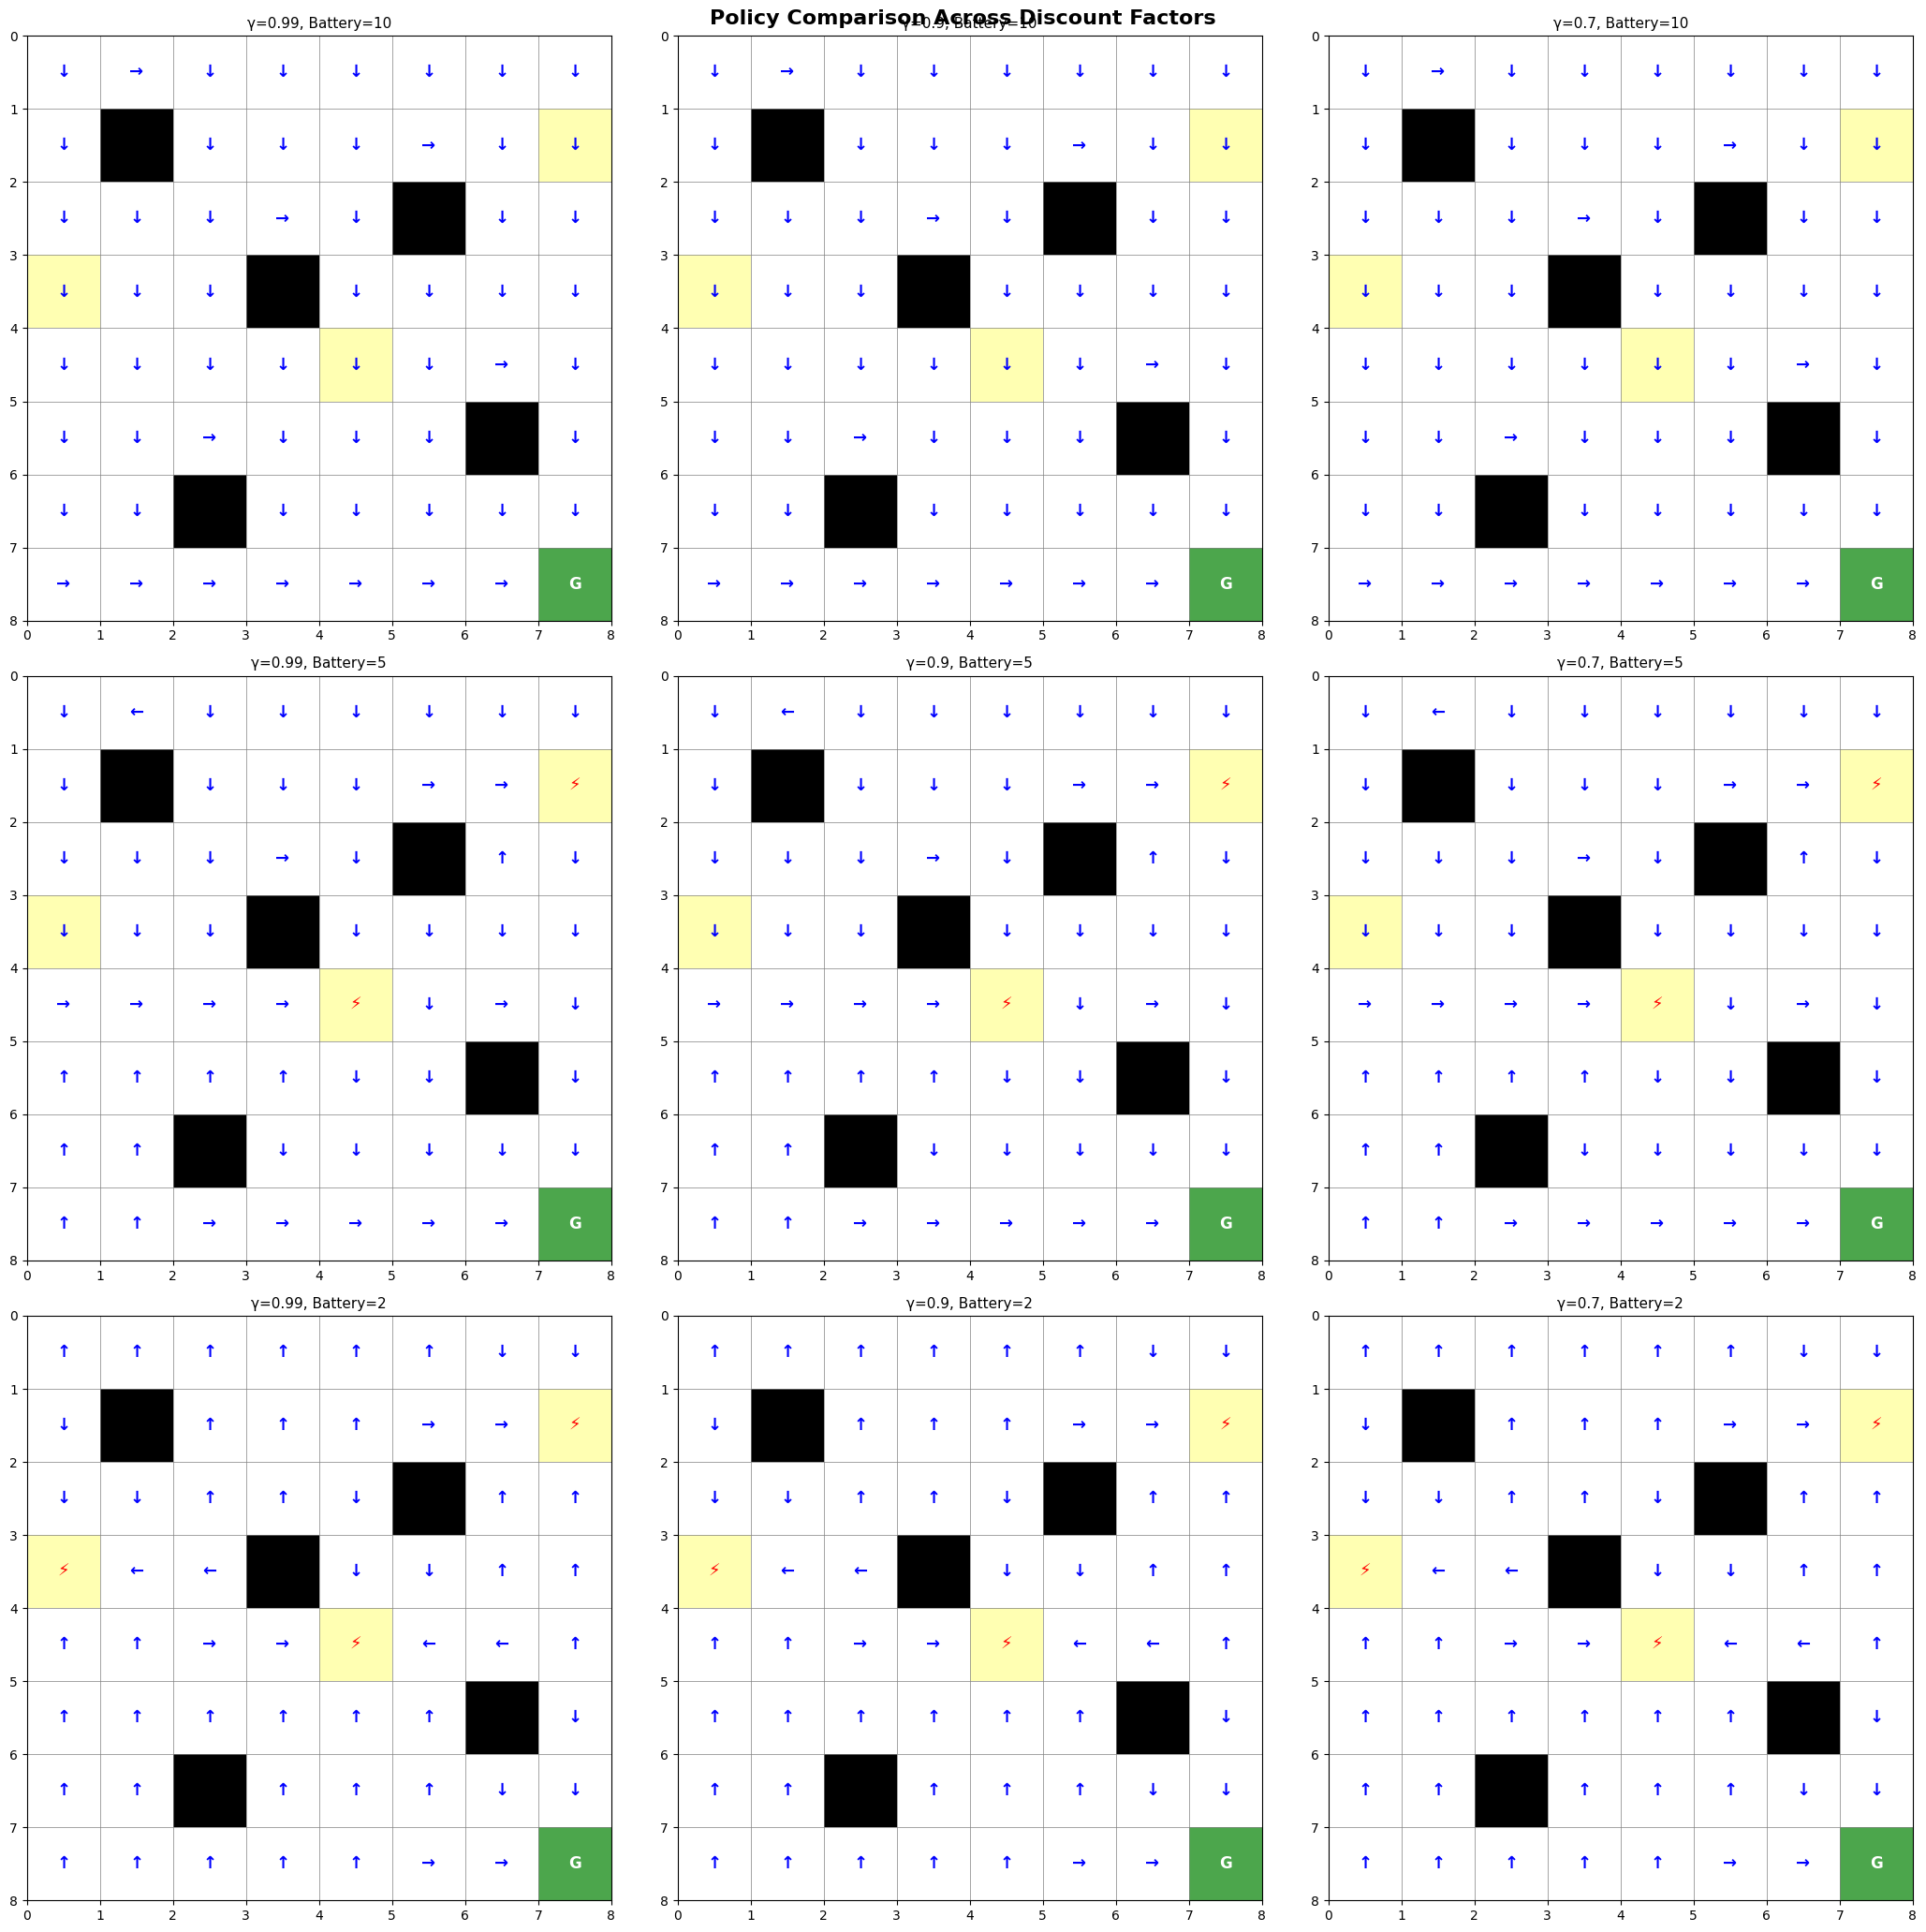

Saved: battery_policy_comparison.png

(e) BATTERY-AWARENESS ANALYSIS

    BATTERY-AWARENESS EMERGENCE ACROSS DISCOUNT FACTORS:
    
    1. γ = 0.99 (Far-sighted):
       - The robot plans far ahead and values future rewards highly
       - It takes the SHORTEST path to goal, conserving battery
       - Recharging is chosen strategically: only when the robot cannot 
         reach the goal with current battery
       - The robot may take detours to charging stations if it anticipates 
         running out of battery on the direct path
       - Battery conservation emerges naturally from the high discount factor
         valuing the distant goal reward
    
    2. γ = 0.9 (Moderate):
       - The robot is moderately forward-looking
       - It still tries to reach the goal but is less willing to take 
         long detours to charging stations
       - Recharging behavior becomes more "reactive" — the robot recharges 
         when battery is critically low rather than planning ahead
   

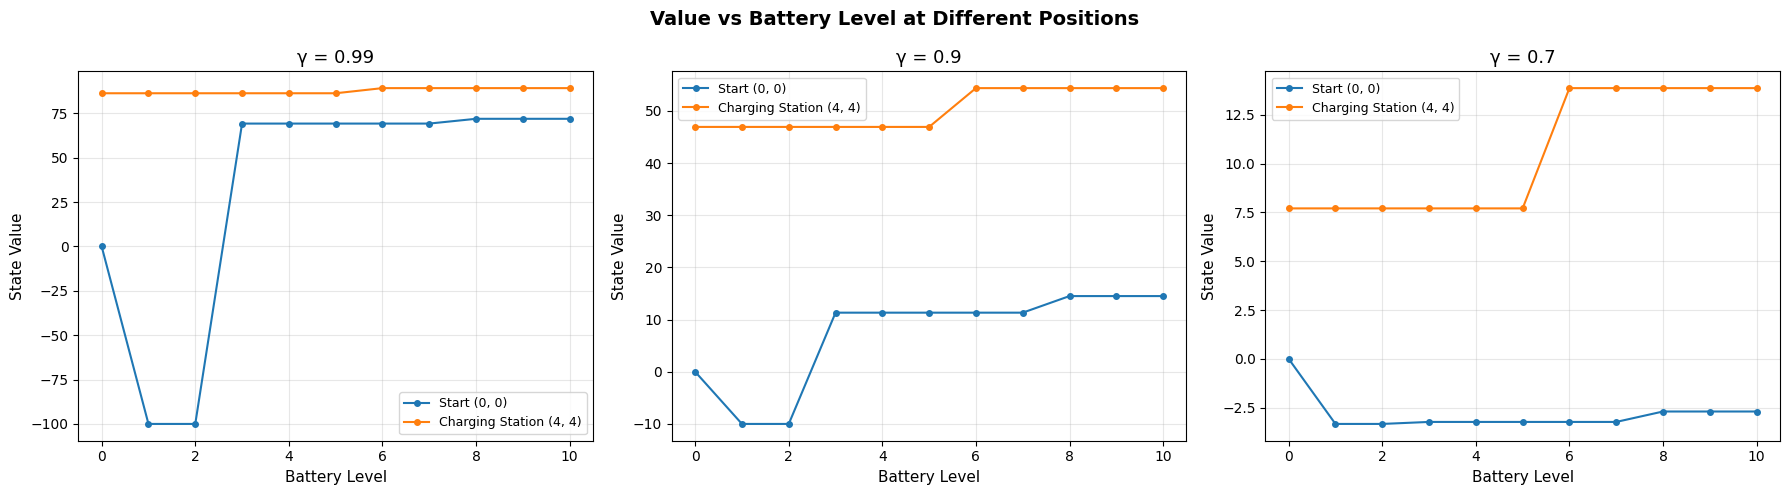

Saved: battery_value_vs_level.png

  Battery level at which robot first chooses to recharge (at charging stations):
    γ=0.99, Station (0, 3): Recharges at battery ≤ 4
    γ=0.99, Station (4, 4): Recharges at battery ≤ 5
    γ=0.99, Station (7, 1): Recharges at battery ≤ 5
    γ=0.9, Station (0, 3): Recharges at battery ≤ 4
    γ=0.9, Station (4, 4): Recharges at battery ≤ 5
    γ=0.9, Station (7, 1): Recharges at battery ≤ 5
    γ=0.7, Station (0, 3): Recharges at battery ≤ 4
    γ=0.7, Station (4, 4): Recharges at battery ≤ 5
    γ=0.7, Station (7, 1): Recharges at battery ≤ 5

(f) MONTE CARLO METHOD AND COMPARISON

--- Monte Carlo, γ=0.99 ---
  MC Episode 20000/80000, Avg V: -6.7045
  MC Episode 40000/80000, Avg V: 20.1582
  MC Episode 60000/80000, Avg V: 27.3840
  MC Episode 80000/80000, Avg V: 30.9099

--- Monte Carlo (γ=0.99) ---
Episodes: 80000
Runtime: 229.3921 seconds
Peak memory: 434.10 KB


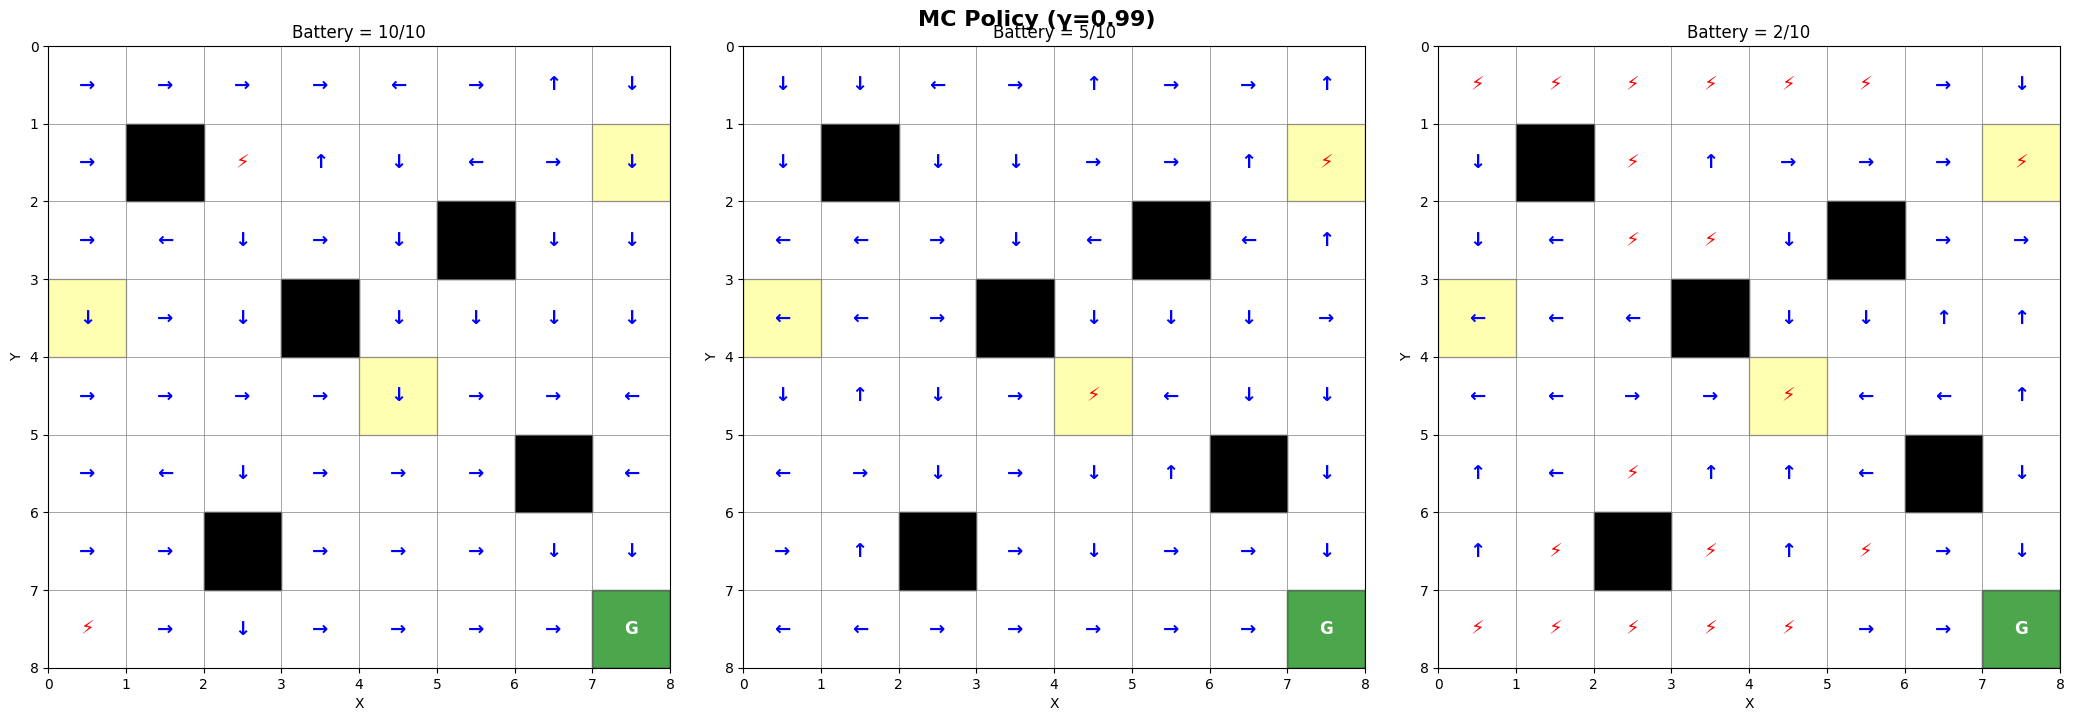

Saved: battery_policy_mc_099.png

--- Monte Carlo, γ=0.9 ---
  MC Episode 20000/80000, Avg V: 12.2161
  MC Episode 40000/80000, Avg V: 14.6840
  MC Episode 60000/80000, Avg V: 15.5640
  MC Episode 80000/80000, Avg V: 16.2680

--- Monte Carlo (γ=0.9) ---
Episodes: 80000
Runtime: 205.0381 seconds
Peak memory: 431.48 KB


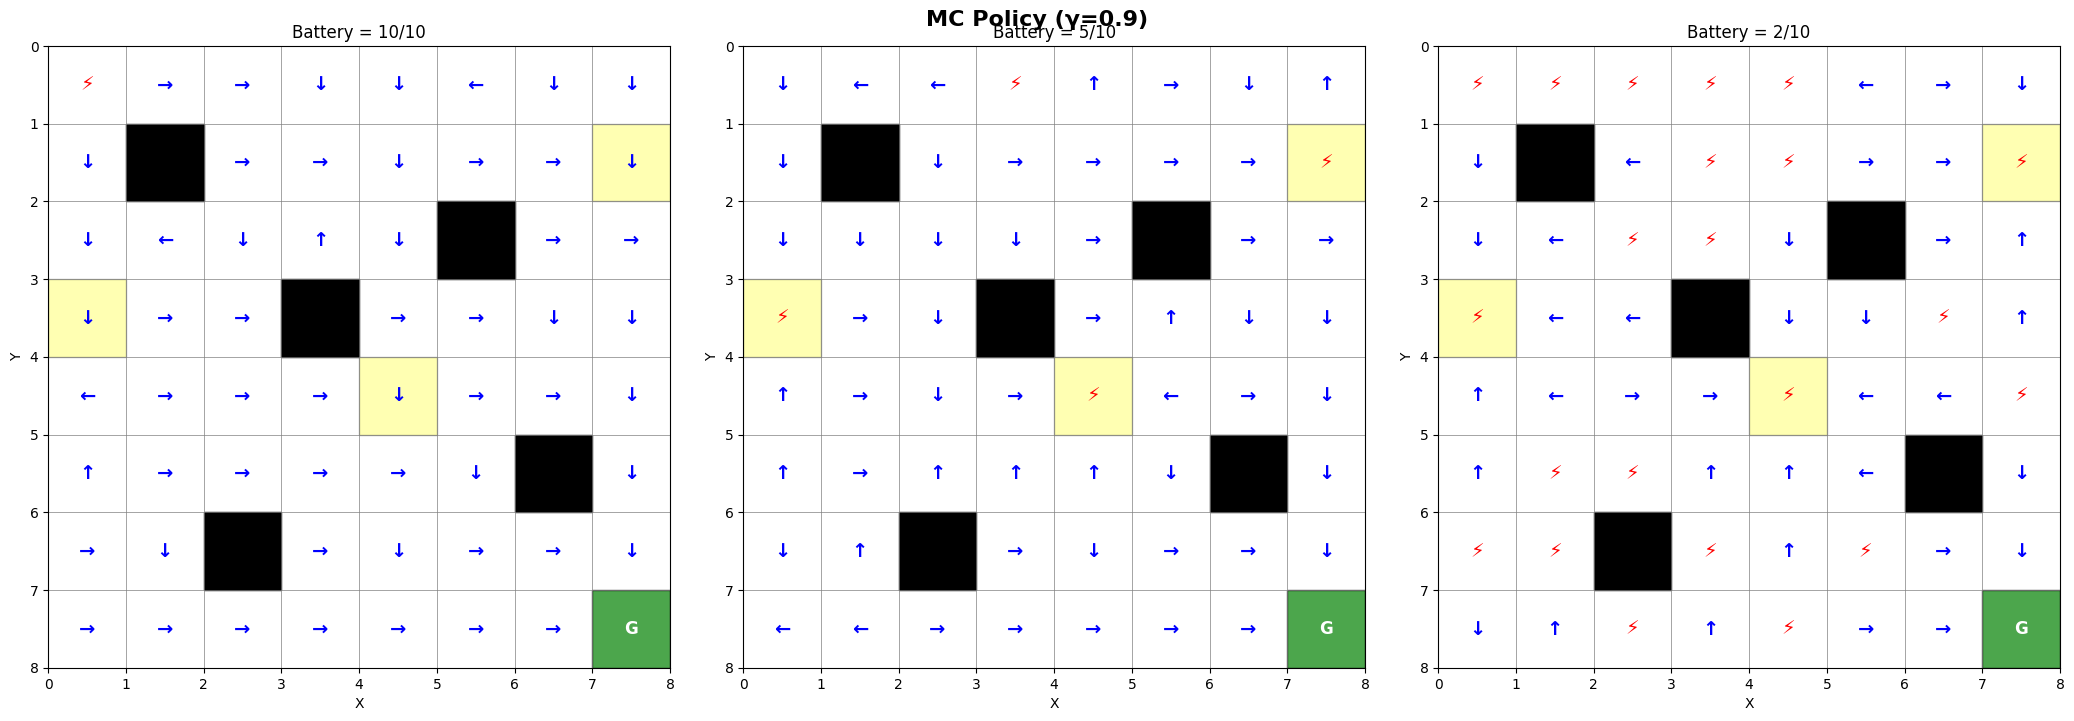

Saved: battery_policy_mc_09.png

--- Monte Carlo, γ=0.7 ---
  MC Episode 20000/80000, Avg V: 1.9627
  MC Episode 40000/80000, Avg V: 2.7576
  MC Episode 60000/80000, Avg V: 2.9835
  MC Episode 80000/80000, Avg V: 3.1641

--- Monte Carlo (γ=0.7) ---
Episodes: 80000
Runtime: 271.3252 seconds
Peak memory: 427.94 KB


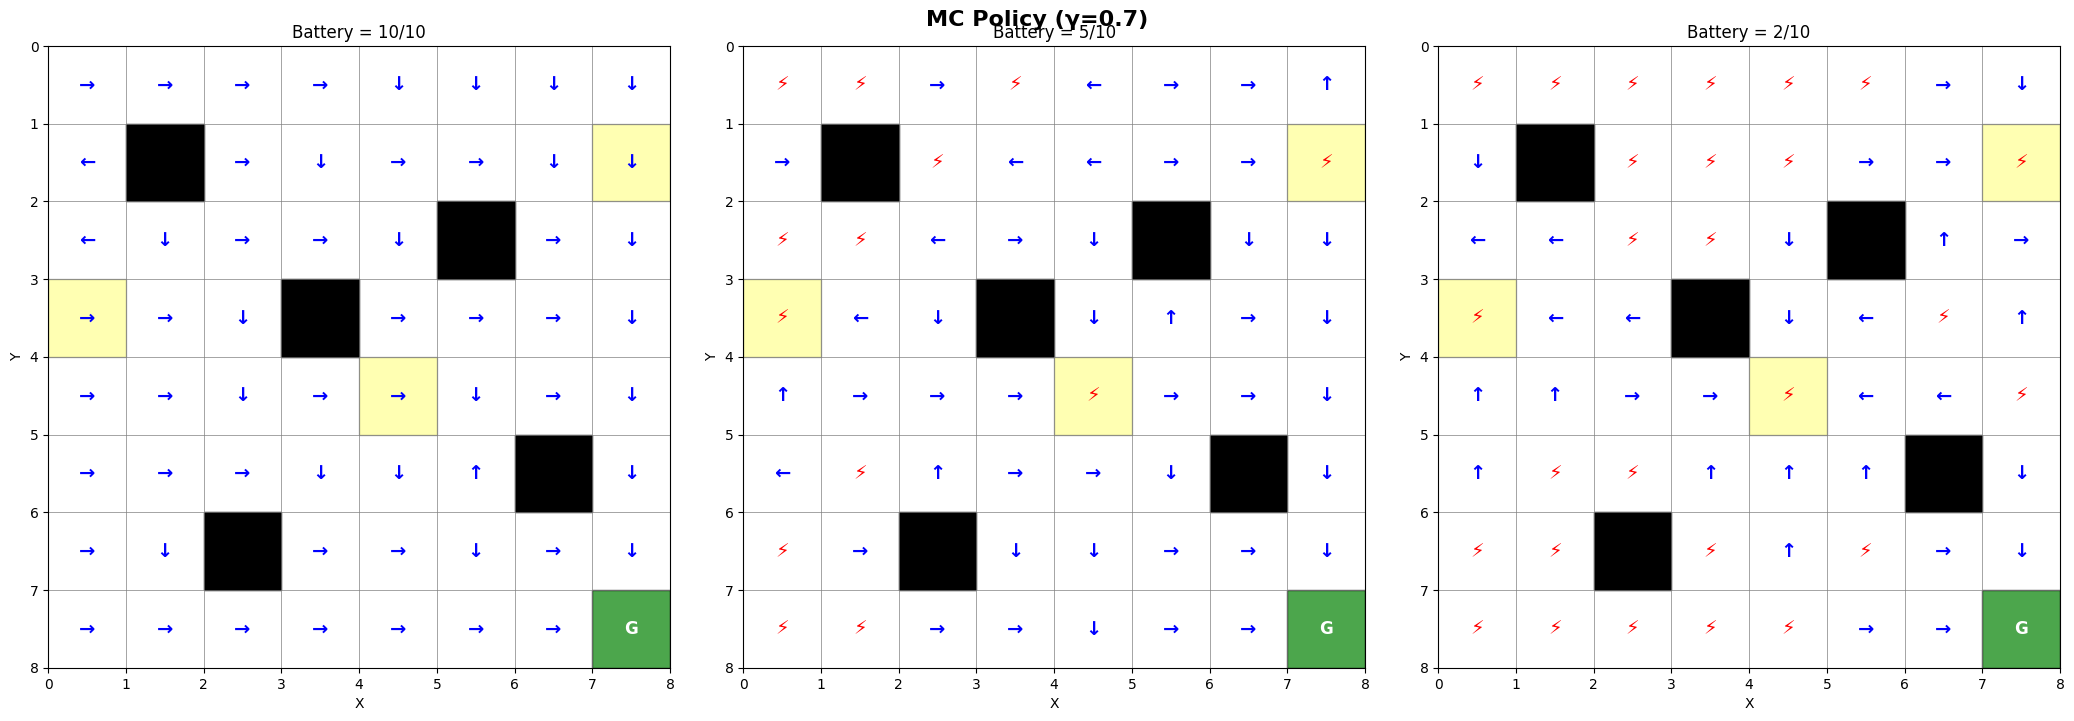

Saved: battery_policy_mc_07.png

COMPREHENSIVE COMPARISON TABLE

Method       | γ      |    Iters/Eps |   Runtime(s) |   Memory(KB) |  Avg V (start)
--------------------------------------------------------------------------------
VI           | 0.99   |         1376 |      29.7422 |       110.24 |        71.9577
PI           | 0.99   |           12 |      78.2794 |        82.41 |        71.9577
MC           | 0.99   |        80000 |     229.3921 |       434.10 |        30.2430
--------------------------------------------------------------------------------
VI           | 0.9    |          133 |       3.8726 |        71.36 |        14.5052
PI           | 0.9    |           12 |       7.2029 |        82.91 |        14.5052
MC           | 0.9    |        80000 |     205.0381 |       431.48 |        -1.8149
--------------------------------------------------------------------------------
VI           | 0.7    |           40 |       1.2500 |        68.27 |        -2.6969
PI           | 0.7  

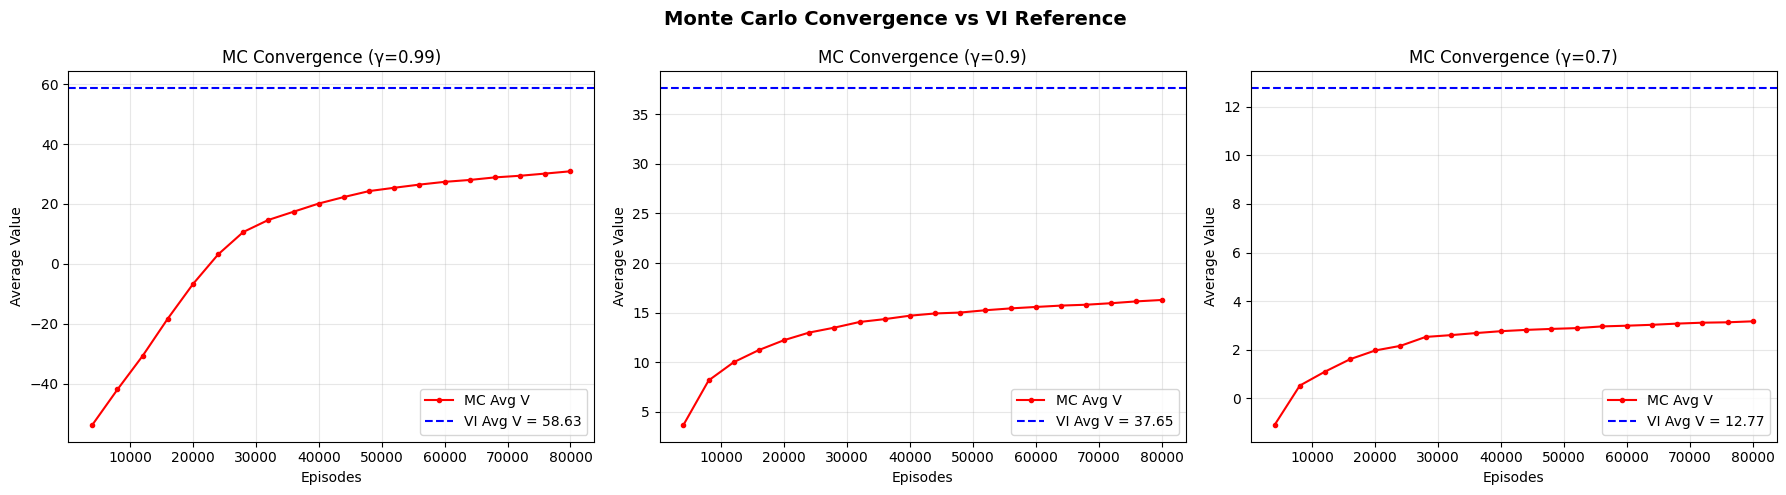

Saved: battery_mc_convergence.png


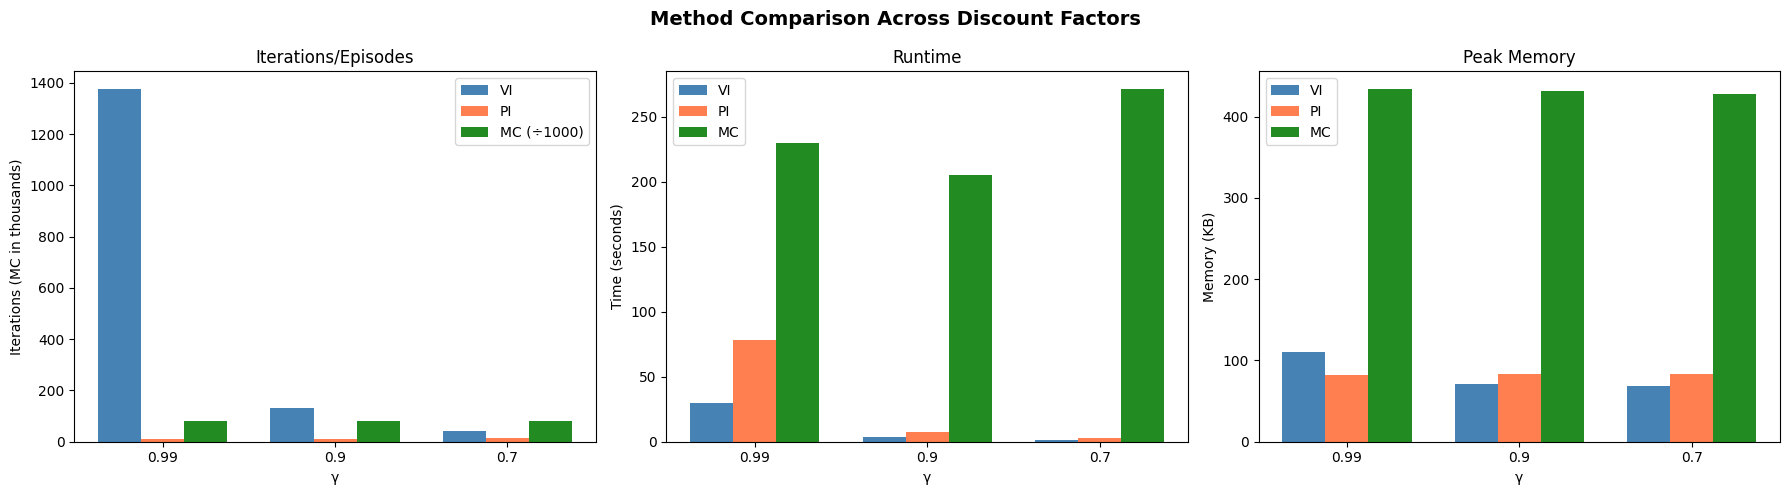

Saved: battery_method_comparison.png

ALL GENERATED FILES

    1.  battery_grid.png                 - Environment layout
    2.  battery_conv_vi_099.png          - VI convergence (γ=0.99)
    3.  battery_policy_vi_099.png        - VI policy at different battery levels (γ=0.99)
    4.  battery_value_vi_099.png         - Value function heatmaps (γ=0.99)
    5.  battery_traj_099.png             - Optimal trajectory (γ=0.99)
    6.  battery_policy_vi_09.png         - VI policy (γ=0.9)
    7.  battery_conv_vi_09.png           - VI convergence (γ=0.9)
    8.  battery_policy_vi_07.png         - VI policy (γ=0.7)
    9.  battery_conv_vi_07.png           - VI convergence (γ=0.7)
    10. battery_policy_comparison.png    - Side-by-side policy comparison
    11. battery_value_vs_level.png       - Value vs battery level analysis
    12. battery_policy_mc_099.png        - MC policy (γ=0.99)
    13. battery_policy_mc_09.png         - MC policy (γ=0.9)
    14. battery_policy_mc_07.png         - MC pol

In [ ]:
import numpy as np
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import copy

# ============================================================================
# ENVIRONMENT SETUP
# ============================================================================

class BatteryAwareRobotMDP:
    """
    Battery-Aware Robot Navigation MDP.
    State: (x, y, b) where b is battery level
    Actions: Up(0), Down(1), Left(2), Right(3), Recharge(4)
    """

    def __init__(self, grid_size=8, max_battery=10, obstacles=None,
                 charging_stations=None, goal=None, start=None, seed=42):
        self.grid_size = grid_size
        self.max_battery = max_battery
        self.battery_levels = list(range(0, max_battery + 1))  # 0 to B

        # Actions: Up, Down, Left, Right, Recharge
        self.actions = [0, 1, 2, 3, 4]
        self.action_names = ['Up', 'Down', 'Left', 'Right', 'Recharge']

        # Direction vectors for movement actions
        self.dx = [0, 0, -1, 1, 0]   # Up, Down, Left, Right, Recharge
        self.dy = [-1, 1, 0, 0, 0]

        # Rewards
        self.move_reward = -1
        self.recharge_reward = -2
        self.failure_reward = -100
        self.goal_reward = 100

        random.seed(seed)
        np.random.seed(seed)

        # Place obstacles
        if obstacles is None:
            all_cells = [(x, y) for x in range(grid_size) for y in range(grid_size)]
            random.shuffle(all_cells)
            self.obstacles = set()
            idx = 0
            count = 0
            while count < 5 and idx < len(all_cells):
                cell = all_cells[idx]
                idx += 1
                self.obstacles.add(cell)
                count += 1
        else:
            self.obstacles = set(obstacles)

        # Place charging stations
        if charging_stations is None:
            self.charging_stations = set()
            remaining = [c for c in all_cells[idx:] if c not in self.obstacles]
            random.shuffle(remaining)
            for i in range(min(3, len(remaining))):
                self.charging_stations.add(remaining[i])
        else:
            self.charging_stations = set(charging_stations)

        # Place goal
        if goal is None:
            for c in remaining[3:]:
                if c not in self.obstacles and c not in self.charging_stations:
                    self.goal = c
                    break
        else:
            self.goal = goal

        # Start position
        if start is None:
            for c in remaining[4:]:
                if c not in self.obstacles and c not in self.charging_stations and c != self.goal:
                    self.start = c
                    break
        else:
            self.start = start

        # Terminal state
        self.terminal_state = 'TERMINAL'

        # Build state space
        self.states = []
        for x in range(grid_size):
            for y in range(grid_size):
                if (x, y) not in self.obstacles:
                    for b in self.battery_levels:
                        self.states.append((x, y, b))

        self.n_states = len(self.states)
        self.n_actions = len(self.actions)

        print(f"=" * 60)
        print(f"Battery-Aware Robot Navigation MDP")
        print(f"=" * 60)
        print(f"Grid Size: {grid_size}x{grid_size}")
        print(f"Max Battery: {max_battery}")
        print(f"Obstacles: {sorted(self.obstacles)}")
        print(f"Charging Stations: {sorted(self.charging_stations)}")
        print(f"Goal: {self.goal}")
        print(f"Start: {self.start}")
        print(f"Number of states: {self.n_states} + terminal")
        print(f"Number of actions: {self.n_actions}")
        print(f"=" * 60)

        # Precompute transitions
        self._build_transitions()

    def _is_valid_cell(self, x, y):
        """Check if cell is within bounds and not obstacle."""
        return (0 <= x < self.grid_size and 0 <= y < self.grid_size
                and (x, y) not in self.obstacles)

    def _build_transitions(self):
        """
        Build transition dictionary.
        transitions[state][action] = list of (probability, next_state, reward, done)

        Transitions are deterministic for simplicity (prob=1.0).
        """
        self.transitions = {}

        for s in self.states:
            x, y, b = s
            self.transitions[s] = {}

            # If battery is 0 and not at charging station -> terminal failure
            if b == 0 and (x, y) not in self.charging_stations:
                for a in self.actions:
                    self.transitions[s][a] = [(1.0, self.terminal_state, self.failure_reward, True)]
                continue

            # If at goal -> terminal (regardless of battery)
            if (x, y) == self.goal:
                for a in self.actions:
                    self.transitions[s][a] = [(1.0, self.terminal_state, 0, True)]
                continue

            for a in self.actions:
                if a == 4:  # Recharge
                    if (x, y) in self.charging_stations and b < self.max_battery:
                        # Recharge: battery goes to max
                        new_b = self.max_battery
                        self.transitions[s][a] = [(1.0, (x, y, new_b),
                                                   self.recharge_reward, False)]
                    else:
                        # Cannot recharge: stay in place with move penalty
                        # (invalid action - penalize as wasted move)
                        self.transitions[s][a] = [(1.0, s, self.move_reward, False)]
                else:
                    # Movement action
                    if b == 0:
                        # No battery for movement at charging station
                        # Must recharge first
                        self.transitions[s][a] = [(1.0, s, self.move_reward, False)]
                        continue

                    nx = x + self.dx[a]
                    ny = y + self.dy[a]
                    new_b = b - 1  # Consume battery

                    if not self._is_valid_cell(nx, ny):
                        # Hit wall or obstacle: stay in place, still consume battery
                        if new_b == 0 and (x, y) not in self.charging_stations:
                            # Battery depleted away from charger
                            self.transitions[s][a] = [(1.0, self.terminal_state,
                                                       self.move_reward + self.failure_reward, True)]
                        else:
                            self.transitions[s][a] = [(1.0, (x, y, new_b),
                                                       self.move_reward, False)]
                    else:
                        # Valid move
                        if (nx, ny) == self.goal:
                            # Reached goal!
                            self.transitions[s][a] = [(1.0, self.terminal_state,
                                                       self.move_reward + self.goal_reward, True)]
                        elif new_b == 0 and (nx, ny) not in self.charging_stations:
                            # Battery depleted away from charger
                            self.transitions[s][a] = [(1.0, self.terminal_state,
                                                       self.move_reward + self.failure_reward, True)]
                        else:
                            self.transitions[s][a] = [(1.0, (nx, ny, new_b),
                                                       self.move_reward, False)]

    def get_transitions(self, state, action):
        """Return list of (prob, next_state, reward, done)."""
        if state == self.terminal_state:
            return [(1.0, self.terminal_state, 0, True)]
        return self.transitions[state][action]


# ============================================================================
# VALUE ITERATION
# ============================================================================

def value_iteration(mdp, gamma=0.99, theta=1e-6, max_iterations=2000):
    """Value Iteration algorithm."""
    tracemalloc.start()
    start_time = time.time()

    V = {s: 0.0 for s in mdp.states}
    V[mdp.terminal_state] = 0.0

    deltas = []

    for iteration in range(1, max_iterations + 1):
        delta = 0
        V_new = {}

        for s in mdp.states:
            x, y, b = s

            # Terminal conditions handled in transitions
            if (x, y) == mdp.goal:
                V_new[s] = 0.0
                continue
            if b == 0 and (x, y) not in mdp.charging_stations:
                V_new[s] = 0.0
                continue

            action_values = []
            for a in mdp.actions:
                q_val = 0.0
                for prob, ns, reward, done in mdp.get_transitions(s, a):
                    if done:
                        q_val += prob * reward
                    else:
                        q_val += prob * (reward + gamma * V.get(ns, 0))
                action_values.append(q_val)

            V_new[s] = max(action_values)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        V[mdp.terminal_state] = 0.0
        deltas.append(delta)

        if delta < theta:
            break

    # Extract policy
    policy = {}
    for s in mdp.states:
        x, y, b = s
        if (x, y) == mdp.goal or (b == 0 and (x, y) not in mdp.charging_stations):
            policy[s] = 0
            continue

        action_values = []
        for a in mdp.actions:
            q_val = 0.0
            for prob, ns, reward, done in mdp.get_transitions(s, a):
                if done:
                    q_val += prob * reward
                else:
                    q_val += prob * (reward + gamma * V.get(ns, 0))
            action_values.append(q_val)
        policy[s] = int(np.argmax(action_values))

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n--- Value Iteration (γ={gamma}) ---")
    print(f"Converged in {iteration} iterations")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, iteration, runtime, memory_peak, deltas


# ============================================================================
# POLICY ITERATION
# ============================================================================

def policy_evaluation_battery(mdp, policy, gamma=0.99, theta=1e-6, max_iterations=2000):
    """Evaluate policy for battery MDP."""
    V = {s: 0.0 for s in mdp.states}
    V[mdp.terminal_state] = 0.0

    for _ in range(max_iterations):
        delta = 0
        for s in mdp.states:
            x, y, b = s
            if (x, y) == mdp.goal or (b == 0 and (x, y) not in mdp.charging_stations):
                continue

            a = policy[s]
            v_new = 0.0
            for prob, ns, reward, done in mdp.get_transitions(s, a):
                if done:
                    v_new += prob * reward
                else:
                    v_new += prob * (reward + gamma * V.get(ns, 0))

            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new

        if delta < theta:
            break

    return V


def policy_iteration(mdp, gamma=0.99, max_iterations=100):
    """Policy Iteration algorithm."""
    tracemalloc.start()
    start_time = time.time()

    # Initialize policy: try to move Right by default
    policy = {}
    for s in mdp.states:
        x, y, b = s
        if (x, y) == mdp.goal or (b == 0 and (x, y) not in mdp.charging_stations):
            policy[s] = 0
        elif (x, y) in mdp.charging_stations and b == 0:
            policy[s] = 4  # Recharge
        else:
            policy[s] = 3  # Move Right

    iteration = 0
    for iteration in range(1, max_iterations + 1):
        # Policy Evaluation
        V = policy_evaluation_battery(mdp, policy, gamma)

        # Policy Improvement
        policy_stable = True
        for s in mdp.states:
            x, y, b = s
            if (x, y) == mdp.goal or (b == 0 and (x, y) not in mdp.charging_stations):
                continue

            old_action = policy[s]
            action_values = []
            for a in mdp.actions:
                q_val = 0.0
                for prob, ns, reward, done in mdp.get_transitions(s, a):
                    if done:
                        q_val += prob * reward
                    else:
                        q_val += prob * (reward + gamma * V.get(ns, 0))
                action_values.append(q_val)

            policy[s] = int(np.argmax(action_values))
            if old_action != policy[s]:
                policy_stable = False

        if policy_stable:
            break

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n--- Policy Iteration (γ={gamma}) ---")
    print(f"Converged in {iteration} iterations")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, iteration, runtime, memory_peak


# ============================================================================
# MONTE CARLO METHOD
# ============================================================================

def monte_carlo_battery(mdp, gamma=0.99, num_episodes=50000, epsilon=0.2,
                        record_interval=5000):
    """
    On-policy first-visit MC with epsilon-greedy for battery MDP.
    """
    tracemalloc.start()
    start_time = time.time()

    Q = defaultdict(lambda: np.zeros(mdp.n_actions))
    returns_count = defaultdict(lambda: np.zeros(mdp.n_actions))
    returns_sum = defaultdict(lambda: np.zeros(mdp.n_actions))

    value_history = []

    for ep in range(1, num_episodes + 1):
        # Start from random valid state with some battery
        valid_starts = [s for s in mdp.states
                       if (s[0], s[1]) != mdp.goal
                       and s[2] > 0]
        if not valid_starts:
            continue

        state = random.choice(valid_starts)
        episode = []

        for step in range(300):
            if state == mdp.terminal_state:
                break

            x, y, b = state
            if (x, y) == mdp.goal or (b == 0 and (x, y) not in mdp.charging_stations):
                break

            # Epsilon-greedy
            if random.random() < epsilon:
                action = random.choice(mdp.actions)
            else:
                action = int(np.argmax(Q[state]))

            transitions = mdp.get_transitions(state, action)
            probs = [t[0] for t in transitions]
            idx = np.random.choice(len(transitions), p=probs)
            prob, next_state, reward, done = transitions[idx]

            episode.append((state, action, reward))

            if done:
                break
            state = next_state

        # First-visit MC
        G = 0
        visited = set()
        for t in range(len(episode) - 1, -1, -1):
            s_t, a_t, r_t = episode[t]
            G = gamma * G + r_t

            sa = (s_t, a_t)
            if sa not in visited:
                visited.add(sa)
                returns_sum[s_t][a_t] += G
                returns_count[s_t][a_t] += 1
                Q[s_t][a_t] = returns_sum[s_t][a_t] / returns_count[s_t][a_t]

        if ep % record_interval == 0:
            V_temp = {}
            for s in mdp.states:
                if s in Q and np.any(returns_count[s] > 0):
                    V_temp[s] = np.max(Q[s])
                else:
                    V_temp[s] = 0.0
            valid_v = [V_temp[s] for s in mdp.states
                      if (s[0], s[1]) != mdp.goal and s[2] > 0]
            avg_v = np.mean(valid_v) if valid_v else 0
            value_history.append((ep, avg_v))
            if ep % 20000 == 0:
                print(f"  MC Episode {ep}/{num_episodes}, Avg V: {avg_v:.4f}")

    # Extract final policy and V
    policy = {}
    V = {}
    for s in mdp.states:
        x, y, b = s
        if (x, y) == mdp.goal or (b == 0 and (x, y) not in mdp.charging_stations):
            policy[s] = 0
            V[s] = 0.0
        elif s in Q and np.any(returns_count[s] > 0):
            policy[s] = int(np.argmax(Q[s]))
            V[s] = np.max(Q[s])
        else:
            policy[s] = random.choice(mdp.actions)
            V[s] = 0.0

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n--- Monte Carlo (γ={gamma}) ---")
    print(f"Episodes: {num_episodes}")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, num_episodes, runtime, memory_peak, value_history


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_battery_grid(mdp, title="Battery-Aware Grid"):
    """Visualize grid with obstacles, charging stations, and goal."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    for x in range(mdp.grid_size + 1):
        ax.axhline(y=x, color='gray', linewidth=0.5)
        ax.axvline(x=x, color='gray', linewidth=0.5)

    # Obstacles
    for (ox, oy) in mdp.obstacles:
        rect = plt.Rectangle((ox, oy), 1, 1, facecolor='black', edgecolor='black')
        ax.add_patch(rect)

    # Charging stations
    for (cx, cy) in mdp.charging_stations:
        rect = plt.Rectangle((cx, cy), 1, 1, facecolor='yellow', edgecolor='black', alpha=0.7)
        ax.add_patch(rect)
        ax.text(cx + 0.5, cy + 0.5, '⚡', ha='center', va='center', fontsize=16)

    # Goal
    gx, gy = mdp.goal
    rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.7)
    ax.add_patch(rect)
    ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

    # Start
    sx, sy = mdp.start
    rect = plt.Rectangle((sx, sy), 1, 1, facecolor='blue', edgecolor='black', alpha=0.3)
    ax.add_patch(rect)
    ax.text(sx + 0.5, sy + 0.5, 'S', ha='center', va='center', fontsize=14,
            fontweight='bold', color='blue')

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='black', label='Obstacle'),
        mpatches.Patch(facecolor='yellow', label='Charging Station'),
        mpatches.Patch(facecolor='green', label='Goal'),
        mpatches.Patch(facecolor='blue', alpha=0.3, label='Start'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

    ax.set_xlim(0, mdp.grid_size)
    ax.set_ylim(0, mdp.grid_size)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.savefig('battery_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: battery_grid.png")


def visualize_battery_policy(mdp, policy, battery_levels, title="Policy",
                              filename="battery_policy.png"):
    """
    Visualize policy at different battery levels.
    """
    n_levels = len(battery_levels)
    cols = min(3, n_levels)
    rows = (n_levels + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 7 * rows))
    if n_levels == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)

    arrow_symbols = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: '⚡'}
    arrow_colors = {0: 'blue', 1: 'blue', 2: 'blue', 3: 'blue', 4: 'red'}

    for idx, b_level in enumerate(battery_levels):
        r, c = idx // cols, idx % cols
        ax = axes[r][c]

        # Draw grid
        for x in range(mdp.grid_size + 1):
            ax.axhline(y=x, color='gray', linewidth=0.5)
            ax.axvline(x=x, color='gray', linewidth=0.5)

        # Obstacles
        for (ox, oy) in mdp.obstacles:
            rect = plt.Rectangle((ox, oy), 1, 1, facecolor='black', edgecolor='black')
            ax.add_patch(rect)

        # Charging stations
        for (cx, cy) in mdp.charging_stations:
            rect = plt.Rectangle((cx, cy), 1, 1, facecolor='yellow', edgecolor='black', alpha=0.3)
            ax.add_patch(rect)

        # Goal
        gx, gy = mdp.goal
        rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.7)
        ax.add_patch(rect)
        ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=12,
                fontweight='bold', color='white')

        # Policy arrows
        for x in range(mdp.grid_size):
            for y in range(mdp.grid_size):
                if (x, y) in mdp.obstacles or (x, y) == mdp.goal:
                    continue

                s = (x, y, b_level)
                if s not in policy:
                    continue

                a = policy[s]
                cx_pos, cy_pos = x + 0.5, y + 0.5

                ax.text(cx_pos, cy_pos, arrow_symbols[a], ha='center', va='center',
                       fontsize=14, color=arrow_colors[a], fontweight='bold')

        ax.set_xlim(0, mdp.grid_size)
        ax.set_ylim(0, mdp.grid_size)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_title(f'Battery = {b_level}/{mdp.max_battery}', fontsize=12)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    # Hide empty subplots
    for idx in range(n_levels, rows * cols):
        r, c = idx // cols, idx % cols
        axes[r][c].set_visible(False)

    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def visualize_battery_value_function(mdp, V, battery_levels, title="Value Function",
                                      filename="battery_value.png"):
    """Visualize value function at different battery levels."""
    n_levels = len(battery_levels)
    cols = min(3, n_levels)
    rows = (n_levels + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
    if n_levels == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)

    for idx, b_level in enumerate(battery_levels):
        r, c = idx // cols, idx % cols
        ax = axes[r][c]

        grid = np.full((mdp.grid_size, mdp.grid_size), np.nan)
        for x in range(mdp.grid_size):
            for y in range(mdp.grid_size):
                if (x, y) not in mdp.obstacles:
                    s = (x, y, b_level)
                    grid[y][x] = V.get(s, 0)

        im = ax.imshow(grid, cmap='RdYlGn', interpolation='nearest')
        plt.colorbar(im, ax=ax, shrink=0.8)

        # Mark obstacles
        for (ox, oy) in mdp.obstacles:
            rect = plt.Rectangle((ox - 0.5, oy - 0.5), 1, 1, facecolor='black')
            ax.add_patch(rect)

        # Mark charging stations
        for (cx_s, cy_s) in mdp.charging_stations:
            rect = plt.Rectangle((cx_s - 0.5, cy_s - 0.5), 1, 1,
                                facecolor='none', edgecolor='yellow', linewidth=2)
            ax.add_patch(rect)

        # Mark goal
        gx, gy = mdp.goal
        rect = plt.Rectangle((gx - 0.5, gy - 0.5), 1, 1,
                            facecolor='none', edgecolor='blue', linewidth=3)
        ax.add_patch(rect)

        # Value text
        for x in range(mdp.grid_size):
            for y in range(mdp.grid_size):
                if (x, y) not in mdp.obstacles:
                    s = (x, y, b_level)
                    val = V.get(s, 0)
                    ax.text(x, y, f'{val:.1f}', ha='center', va='center', fontsize=5)

        ax.set_title(f'Battery = {b_level}', fontsize=12)

    for idx in range(n_levels, rows * cols):
        r, c = idx // cols, idx % cols
        axes[r][c].set_visible(False)

    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def plot_convergence_battery(deltas, gamma, title="Convergence", filename="conv.png"):
    """Plot convergence."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(1, len(deltas) + 1), deltas, linewidth=1.5)
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Max Delta', fontsize=12)
    ax.set_title(f'{title} (γ={gamma})', fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def simulate_trajectory(mdp, policy, start_state, max_steps=50):
    """Simulate robot trajectory following policy."""
    trajectory = [start_state]
    state = start_state
    total_reward = 0

    for step in range(max_steps):
        if state == mdp.terminal_state:
            break

        x, y, b = state
        if (x, y) == mdp.goal:
            break
        if b == 0 and (x, y) not in mdp.charging_stations:
            break

        a = policy[state]
        transitions = mdp.get_transitions(state, a)
        _, next_state, reward, done = transitions[0]  # Deterministic

        total_reward += reward
        trajectory.append((state, a, reward, next_state))

        if done:
            break
        state = next_state

    return trajectory, total_reward


def visualize_trajectory(mdp, trajectory, title="Trajectory", filename="trajectory.png"):
    """Visualize a trajectory on the grid."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Grid
    for x in range(mdp.grid_size + 1):
        ax.axhline(y=x, color='gray', linewidth=0.5)
        ax.axvline(x=x, color='gray', linewidth=0.5)

    # Obstacles
    for (ox, oy) in mdp.obstacles:
        rect = plt.Rectangle((ox, oy), 1, 1, facecolor='black', edgecolor='black')
        ax.add_patch(rect)

    # Charging stations
    for (cx, cy) in mdp.charging_stations:
        rect = plt.Rectangle((cx, cy), 1, 1, facecolor='yellow', edgecolor='black', alpha=0.5)
        ax.add_patch(rect)
        ax.text(cx + 0.5, cy + 0.5, '⚡', ha='center', va='center', fontsize=14)

    # Goal
    gx, gy = mdp.goal
    rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.7)
    ax.add_patch(rect)
    ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

    # Draw trajectory
    action_names = ['↑', '↓', '←', '→', '⚡']

    # Start
    start = trajectory[0]
    ax.plot(start[0] + 0.5, start[1] + 0.5, 'bs', markersize=15, label='Start')

    for i, step in enumerate(trajectory[1:]):
        if isinstance(step, tuple) and len(step) == 4:
            s, a, r, ns = step
            x, y, b = s

            # Color based on battery level
            battery_frac = b / mdp.max_battery
            color = plt.cm.RdYlGn(battery_frac)

            ax.text(x + 0.5, y + 0.3, action_names[a], ha='center', va='center',
                   fontsize=12, color='blue', fontweight='bold')
            ax.text(x + 0.5, y + 0.7, f'b={b}', ha='center', va='center',
                   fontsize=8, color='gray')

            # Draw path line
            if ns != mdp.terminal_state and isinstance(ns, tuple):
                nx, ny, nb = ns
                ax.annotate('', xy=(nx + 0.5, ny + 0.5), xytext=(x + 0.5, y + 0.5),
                          arrowprops=dict(arrowstyle='->', color=color, lw=2, alpha=0.7))

    ax.set_xlim(0, mdp.grid_size)
    ax.set_ylim(0, mdp.grid_size)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def print_policy_table_battery(mdp, policy, b_level, title=""):
    """Print policy for a specific battery level."""
    symbols = {0: 'U', 1: 'D', 2: 'L', 3: 'R', 4: 'C'}
    print(f"\n{title} (battery={b_level}):")
    print("-" * 50)
    for y in range(mdp.grid_size):
        row = f" {y} | "
        for x in range(mdp.grid_size):
            if (x, y) in mdp.obstacles:
                row += " X |"
            elif (x, y) == mdp.goal:
                row += " G |"
            else:
                s = (x, y, b_level)
                if s in policy:
                    row += f" {symbols[policy[s]]} |"
                else:
                    row += " ? |"
        print(row)
    print("-" * 50)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("=" * 80)
    print("QUESTION 2: BATTERY-AWARE ROBOT NAVIGATION")
    print("=" * 80)

    # ========================================================================
    # (a) MDP Definition
    # ========================================================================
    print("\n" + "=" * 80)
    print("(a) MDP DEFINITION")
    print("=" * 80)

    # Create environment with specific layout for reproducibility
    obstacles = [(1, 1), (3, 3), (5, 2), (6, 5), (2, 6)]
    charging_stations = [(0, 3), (4, 4), (7, 1)]
    goal = (7, 7)
    start = (0, 0)

    mdp = BatteryAwareRobotMDP(
        grid_size=8,
        max_battery=10,
        obstacles=obstacles,
        charging_stations=charging_stations,
        goal=goal,
        start=start,
        seed=42
    )

    print(f"""
    MDP Definition:
    ===============
    State Space: S = {{(x, y, b) | x ∈ [0,7], y ∈ [0,7], (x,y) ∉ obstacles, b ∈ [0,10]}}
    Total states: {mdp.n_states} (+ terminal)

    Action Space: A = {{Up, Down, Left, Right, Recharge}}

    Transition Model (Deterministic):
    - Move actions (Up/Down/Left/Right):
        * Moves to adjacent cell, battery decreases by 1
        * If target cell is obstacle or boundary: stay in place, battery still decreases
        * If battery reaches 0 away from charging station → TERMINAL (failure)
        * If target cell is goal → TERMINAL (success)
    - Recharge:
        * Only effective at charging stations when b < B_max
        * Restores battery to maximum (B = {mdp.max_battery})
        * If not at charging station or battery full: wasted action (step penalty)

    Terminal Conditions:
    1. Battery = 0 and not at charging station → failure
    2. Reached goal cell → success

    Reward Structure:
    - Move action: {mdp.move_reward}
    - Recharge: {mdp.recharge_reward}
    - Battery failure: {mdp.failure_reward}
    - Goal reached: {mdp.goal_reward}

    Environment:
    - Obstacles: {sorted(mdp.obstacles)}
    - Charging Stations: {sorted(mdp.charging_stations)}
    - Goal: {mdp.goal}
    - Start: {mdp.start}
    """)

    # Visualize grid
    visualize_battery_grid(mdp, "Battery-Aware Navigation Environment")

    # ========================================================================
    # (b) Value Iteration Solution
    # ========================================================================
    print("\n" + "=" * 80)
    print("(b) VALUE ITERATION SOLUTION (γ=0.99)")
    print("=" * 80)

    V_vi_99, pol_vi_99, iters_vi_99, time_vi_99, mem_vi_99, deltas_99 = value_iteration(
        mdp, gamma=0.99
    )

    # Print policies at different battery levels
    for b in [10, 5, 2, 1]:
        print_policy_table_battery(mdp, pol_vi_99, b, f"Policy (VI, γ=0.99)")

    # Visualize
    plot_convergence_battery(deltas_99, 0.99, "VI Convergence", "battery_conv_vi_099.png")

    battery_display = [10, 5, 2, 1]
    visualize_battery_policy(mdp, pol_vi_99, battery_display,
                            "Policy (VI, γ=0.99)", "battery_policy_vi_099.png")
    visualize_battery_value_function(mdp, V_vi_99, battery_display,
                                     "Value Function (VI, γ=0.99)", "battery_value_vi_099.png")

    # Simulate trajectory
    start_state = (mdp.start[0], mdp.start[1], mdp.max_battery)
    traj, total_r = simulate_trajectory(mdp, pol_vi_99, start_state)
    print(f"\nTrajectory from start with full battery:")
    print(f"  Steps: {len(traj) - 1}")
    print(f"  Total reward: {total_r:.2f}")
    for i, step in enumerate(traj[1:]):
        if isinstance(step, tuple) and len(step) == 4:
            s, a, r, ns = step
            print(f"  Step {i+1}: {s} --{mdp.action_names[a]}--> "
                  f"{'TERMINAL' if ns == 'TERMINAL' else ns} (R={r})")

    visualize_trajectory(mdp, traj, "Optimal Trajectory (γ=0.99)", "battery_traj_099.png")

    # ========================================================================
    # (c) Different Discount Factors
    # ========================================================================
    print("\n" + "=" * 80)
    print("(c) COMPARISON ACROSS DISCOUNT FACTORS")
    print("=" * 80)

    gammas = [0.99, 0.9, 0.7]
    vi_results = {}
    pi_results = {}

    for gamma in gammas:
        print(f"\n{'='*40} γ = {gamma} {'='*40}")

        # Value Iteration
        V_vi, pol_vi, it_vi, t_vi, m_vi, d_vi = value_iteration(mdp, gamma=gamma)
        vi_results[gamma] = {
            'V': V_vi, 'policy': pol_vi, 'iterations': it_vi,
            'runtime': t_vi, 'memory': m_vi, 'deltas': d_vi
        }

        # Policy Iteration
        V_pi, pol_pi, it_pi, t_pi, m_pi = policy_iteration(mdp, gamma=gamma)
        pi_results[gamma] = {
            'V': V_pi, 'policy': pol_pi, 'iterations': it_pi,
            'runtime': t_pi, 'memory': m_pi
        }

        # Visualize policy
        visualize_battery_policy(mdp, pol_vi, [10, 5, 2],
                                f"Policy (VI, γ={gamma})",
                                f"battery_policy_vi_{str(gamma).replace('.','')}.png")

        # Convergence
        plot_convergence_battery(d_vi, gamma, "VI Convergence",
                                f"battery_conv_vi_{str(gamma).replace('.','')}.png")

        # Trajectory
        start_state = (mdp.start[0], mdp.start[1], mdp.max_battery)
        traj, total_r = simulate_trajectory(mdp, pol_vi, start_state)
        print(f"  Trajectory length: {len(traj)-1}, Total reward: {total_r:.2f}")

    # ========================================================================
    # (d) Compare Policies
    # ========================================================================
    print("\n" + "=" * 80)
    print("(d) POLICY COMPARISON ACROSS DISCOUNT FACTORS")
    print("=" * 80)

    # Comparison table
    print(f"""
    ┌─────────────────────────┬────────────┬────────────┬────────────┐
    │ Metric                  │  γ = 0.99  │  γ = 0.9   │  γ = 0.7   │
    ├─────────────────────────┼────────────┼────────────┼────────────┤
    │ VI Iterations           │ {vi_results[0.99]['iterations']:>10} │ {vi_results[0.9]['iterations']:>10} │ {vi_results[0.7]['iterations']:>10} │
    │ VI Runtime (s)          │ {vi_results[0.99]['runtime']:>10.4f} │ {vi_results[0.9]['runtime']:>10.4f} │ {vi_results[0.7]['runtime']:>10.4f} │
    │ VI Memory (KB)          │ {vi_results[0.99]['memory']:>10.2f} │ {vi_results[0.9]['memory']:>10.2f} │ {vi_results[0.7]['memory']:>10.2f} │
    │ PI Iterations           │ {pi_results[0.99]['iterations']:>10} │ {pi_results[0.9]['iterations']:>10} │ {pi_results[0.7]['iterations']:>10} │
    │ PI Runtime (s)          │ {pi_results[0.99]['runtime']:>10.4f} │ {pi_results[0.9]['runtime']:>10.4f} │ {pi_results[0.7]['runtime']:>10.4f} │
    │ PI Memory (KB)          │ {pi_results[0.99]['memory']:>10.2f} │ {pi_results[0.9]['memory']:>10.2f} │ {pi_results[0.7]['memory']:>10.2f} │
    └─────────────────────────┴────────────┴────────────┴────────────┘
    """)

    # Policy differences between gammas
    for g1, g2 in [(0.99, 0.9), (0.9, 0.7), (0.99, 0.7)]:
        match = sum(1 for s in mdp.states if vi_results[g1]['policy'].get(s) == vi_results[g2]['policy'].get(s))
        print(f"  Policy match γ={g1} vs γ={g2}: {match}/{len(mdp.states)} states")

    # Count recharge actions for each gamma
    print("\n  Recharge action frequency in policy:")
    for gamma in gammas:
        recharge_count = sum(1 for s in mdp.states if vi_results[gamma]['policy'].get(s) == 4)
        total_valid = sum(1 for s in mdp.states
                         if (s[0], s[1]) != mdp.goal
                         and not (s[2] == 0 and (s[0], s[1]) not in mdp.charging_stations))
        print(f"    γ={gamma}: {recharge_count}/{total_valid} states choose Recharge "
              f"({100*recharge_count/max(1,total_valid):.1f}%)")

    # Side-by-side comparison figure
    fig, axes = plt.subplots(3, 3, figsize=(21, 21))
    arrow_symbols = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: '⚡'}
    arrow_colors = {0: 'blue', 1: 'blue', 2: 'blue', 3: 'blue', 4: 'red'}

    b_levels_show = [10, 5, 2]

    for col, gamma in enumerate(gammas):
        for row, b_level in enumerate(b_levels_show):
            ax = axes[row][col]
            policy = vi_results[gamma]['policy']

            for x in range(mdp.grid_size + 1):
                ax.axhline(y=x, color='gray', linewidth=0.5)
                ax.axvline(x=x, color='gray', linewidth=0.5)

            for (ox, oy) in mdp.obstacles:
                rect = plt.Rectangle((ox, oy), 1, 1, facecolor='black')
                ax.add_patch(rect)

            for (cx, cy) in mdp.charging_stations:
                rect = plt.Rectangle((cx, cy), 1, 1, facecolor='yellow', alpha=0.3)
                ax.add_patch(rect)

            gx, gy = mdp.goal
            rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', alpha=0.7)
            ax.add_patch(rect)
            ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=12,
                   fontweight='bold', color='white')

            for x in range(mdp.grid_size):
                for y in range(mdp.grid_size):
                    if (x, y) in mdp.obstacles or (x, y) == mdp.goal:
                        continue
                    s = (x, y, b_level)
                    if s in policy:
                        a = policy[s]
                        ax.text(x + 0.5, y + 0.5, arrow_symbols[a], ha='center',
                               va='center', fontsize=13, color=arrow_colors[a], fontweight='bold')

            ax.set_xlim(0, mdp.grid_size)
            ax.set_ylim(0, mdp.grid_size)
            ax.set_aspect('equal')
            ax.invert_yaxis()
            ax.set_title(f'γ={gamma}, Battery={b_level}', fontsize=11)

    fig.suptitle('Policy Comparison Across Discount Factors', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('battery_policy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: battery_policy_comparison.png")

    # ========================================================================
    # (e) Battery-Awareness Analysis
    # ========================================================================
    print("\n" + "=" * 80)
    print("(e) BATTERY-AWARENESS ANALYSIS")
    print("=" * 80)

    print("""
    BATTERY-AWARENESS EMERGENCE ACROSS DISCOUNT FACTORS:
    ====================================================

    1. γ = 0.99 (Far-sighted):
       - The robot plans far ahead and values future rewards highly
       - It takes the SHORTEST path to goal, conserving battery
       - Recharging is chosen strategically: only when the robot cannot
         reach the goal with current battery
       - The robot may take detours to charging stations if it anticipates
         running out of battery on the direct path
       - Battery conservation emerges naturally from the high discount factor
         valuing the distant goal reward

    2. γ = 0.9 (Moderate):
       - The robot is moderately forward-looking
       - It still tries to reach the goal but is less willing to take
         long detours to charging stations
       - Recharging behavior becomes more "reactive" — the robot recharges
         when battery is critically low rather than planning ahead
       - Some paths that were optimal at γ=0.99 become suboptimal because
         the discounted goal reward is lower

    3. γ = 0.7 (Short-sighted):
       - The robot heavily discounts future rewards
       - Goal reward of 100 at distance d is worth only 100 × 0.7^d
       - For d=10 steps: 100 × 0.7^10 ≈ 2.82 (barely worth pursuing!)
       - The robot becomes very conservative about battery usage
       - It may prefer to stay near charging stations or take very short
         paths rather than risk battery depletion
       - Recharging becomes more frequent because the penalty for battery
         failure (-100) is immediate while goal reward is heavily discounted
       - Battery-awareness shifts from "strategic planning" to "survival mode"

    KEY INSIGHT:
    The discount factor fundamentally changes HOW battery-awareness manifests:
    - High γ: "Plan the route to have enough battery" (proactive)
    - Medium γ: "Recharge when getting low" (reactive)
    - Low γ: "Stay safe, avoid battery death" (defensive)

    This parallels real-world robot behavior:
    - Long mission planning (high γ): optimize route for energy efficiency
    - Short-term operation (low γ): prioritize immediate safety
    """)

    # Battery level vs Value analysis
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for idx, gamma in enumerate(gammas):
        ax = axes[idx]
        V = vi_results[gamma]['V']

        # Plot value vs battery for different positions
        positions = [mdp.start, mdp.goal,
                    list(mdp.charging_stations)[0] if mdp.charging_stations else (0,0)]
        pos_labels = ['Start', 'Goal', 'Charging Station']

        for pos, label in zip(positions, pos_labels):
            if pos == mdp.goal:
                continue
            values = []
            for b in range(mdp.max_battery + 1):
                s = (pos[0], pos[1], b)
                values.append(V.get(s, 0))
            ax.plot(range(mdp.max_battery + 1), values, 'o-', label=f'{label} {pos}',
                   markersize=4)

        ax.set_xlabel('Battery Level', fontsize=11)
        ax.set_ylabel('State Value', fontsize=11)
        ax.set_title(f'γ = {gamma}', fontsize=13)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle('Value vs Battery Level at Different Positions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('battery_value_vs_level.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: battery_value_vs_level.png")

    # Recharge threshold analysis
    print("\n  Battery level at which robot first chooses to recharge (at charging stations):")
    for gamma in gammas:
        policy = vi_results[gamma]['policy']
        for cs in sorted(mdp.charging_stations):
            for b in range(mdp.max_battery, -1, -1):
                s = (cs[0], cs[1], b)
                if s in policy and policy[s] == 4:  # Recharge
                    print(f"    γ={gamma}, Station {cs}: Recharges at battery ≤ {b}")
                    break

    # ========================================================================
    # (f) Monte Carlo Comparison
    # ========================================================================
    print("\n" + "=" * 80)
    print("(f) MONTE CARLO METHOD AND COMPARISON")
    print("=" * 80)

    mc_results = {}
    for gamma in gammas:
        print(f"\n--- Monte Carlo, γ={gamma} ---")
        V_mc, pol_mc, eps, t_mc, m_mc, mc_hist = monte_carlo_battery(
            mdp, gamma=gamma, num_episodes=80000, epsilon=0.15, record_interval=4000
        )
        mc_results[gamma] = {
            'V': V_mc, 'policy': pol_mc, 'episodes': eps,
            'runtime': t_mc, 'memory': m_mc, 'history': mc_hist
        }

        # Visualize MC policy
        visualize_battery_policy(mdp, pol_mc, [10, 5, 2],
                                f"MC Policy (γ={gamma})",
                                f"battery_policy_mc_{str(gamma).replace('.','')}.png")

    # Full comparison table
    print("\n" + "=" * 100)
    print("COMPREHENSIVE COMPARISON TABLE")
    print("=" * 100)

    print(f"\n{'Method':<12} | {'γ':<6} | {'Iters/Eps':>12} | {'Runtime(s)':>12} | "
          f"{'Memory(KB)':>12} | {'Avg V (start)':>14}")
    print("-" * 80)

    for gamma in gammas:
        # VI
        vi = vi_results[gamma]
        start_s = (mdp.start[0], mdp.start[1], mdp.max_battery)
        v_start_vi = vi['V'].get(start_s, 0)
        print(f"{'VI':<12} | {gamma:<6} | {vi['iterations']:>12} | "
              f"{vi['runtime']:>12.4f} | {vi['memory']:>12.2f} | {v_start_vi:>14.4f}")

        # PI
        pi = pi_results[gamma]
        v_start_pi = pi['V'].get(start_s, 0)
        print(f"{'PI':<12} | {gamma:<6} | {pi['iterations']:>12} | "
              f"{pi['runtime']:>12.4f} | {pi['memory']:>12.2f} | {v_start_pi:>14.4f}")

        # MC
        mc = mc_results[gamma]
        v_start_mc = mc['V'].get(start_s, 0)
        print(f"{'MC':<12} | {gamma:<6} | {mc['episodes']:>12} | "
              f"{mc['runtime']:>12.4f} | {mc['memory']:>12.2f} | {v_start_mc:>14.4f}")

        print("-" * 80)

    # Policy agreement analysis
    print("\nPolicy Agreement (fraction of matching actions):")
    for gamma in gammas:
        vi_pol = vi_results[gamma]['policy']
        pi_pol = pi_results[gamma]['policy']
        mc_pol = mc_results[gamma]['policy']

        valid = [s for s in mdp.states
                if (s[0], s[1]) != mdp.goal
                and not (s[2] == 0 and (s[0], s[1]) not in mdp.charging_stations)]

        vi_pi = sum(1 for s in valid if vi_pol.get(s) == pi_pol.get(s))
        vi_mc = sum(1 for s in valid if vi_pol.get(s) == mc_pol.get(s))
        pi_mc = sum(1 for s in valid if pi_pol.get(s) == mc_pol.get(s))

        n = len(valid)
        print(f"  γ={gamma}: VI-PI: {vi_pi}/{n} ({100*vi_pi/n:.1f}%), "
              f"VI-MC: {vi_mc}/{n} ({100*vi_mc/n:.1f}%), "
              f"PI-MC: {pi_mc}/{n} ({100*pi_mc/n:.1f}%)")

    # MC Convergence comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, gamma in enumerate(gammas):
        ax = axes[idx]
        hist = mc_results[gamma]['history']
        if hist:
            eps_list = [h[0] for h in hist]
            vals = [h[1] for h in hist]
            ax.plot(eps_list, vals, 'r-o', markersize=3, label='MC Avg V')

            # Add VI reference line
            valid_states = [s for s in mdp.states
                          if (s[0], s[1]) != mdp.goal and s[2] > 0]
            vi_avg = np.mean([vi_results[gamma]['V'].get(s, 0) for s in valid_states])
            ax.axhline(y=vi_avg, color='blue', linestyle='--', label=f'VI Avg V = {vi_avg:.2f}')

        ax.set_xlabel('Episodes')
        ax.set_ylabel('Average Value')
        ax.set_title(f'MC Convergence (γ={gamma})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle('Monte Carlo Convergence vs VI Reference', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('battery_mc_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: battery_mc_convergence.png")

    # Combined bar chart comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    x_pos = np.arange(len(gammas))
    width = 0.25
    gamma_labels = [str(g) for g in gammas]

    # Iterations
    vi_its = [vi_results[g]['iterations'] for g in gammas]
    pi_its = [pi_results[g]['iterations'] for g in gammas]
    mc_its = [mc_results[g]['episodes'] // 1000 for g in gammas]  # In thousands

    axes[0].bar(x_pos - width, vi_its, width, label='VI', color='steelblue')
    axes[0].bar(x_pos, pi_its, width, label='PI', color='coral')
    axes[0].bar(x_pos + width, mc_its, width, label='MC (÷1000)', color='forestgreen')
    axes[0].set_ylabel('Iterations (MC in thousands)')
    axes[0].set_title('Iterations/Episodes')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(gamma_labels)
    axes[0].set_xlabel('γ')
    axes[0].legend()

    # Runtime
    vi_times = [vi_results[g]['runtime'] for g in gammas]
    pi_times = [pi_results[g]['runtime'] for g in gammas]
    mc_times = [mc_results[g]['runtime'] for g in gammas]

    axes[1].bar(x_pos - width, vi_times, width, label='VI', color='steelblue')
    axes[1].bar(x_pos, pi_times, width, label='PI', color='coral')
    axes[1].bar(x_pos + width, mc_times, width, label='MC', color='forestgreen')
    axes[1].set_ylabel('Time (seconds)')
    axes[1].set_title('Runtime')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(gamma_labels)
    axes[1].set_xlabel('γ')
    axes[1].legend()

    # Memory
    vi_mems = [vi_results[g]['memory'] for g in gammas]
    pi_mems = [pi_results[g]['memory'] for g in gammas]
    mc_mems = [mc_results[g]['memory'] for g in gammas]

    axes[2].bar(x_pos - width, vi_mems, width, label='VI', color='steelblue')
    axes[2].bar(x_pos, pi_mems, width, label='PI', color='coral')
    axes[2].bar(x_pos + width, mc_mems, width, label='MC', color='forestgreen')
    axes[2].set_ylabel('Memory (KB)')
    axes[2].set_title('Peak Memory')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(gamma_labels)
    axes[2].set_xlabel('γ')
    axes[2].legend()

    fig.suptitle('Method Comparison Across Discount Factors', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('battery_method_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: battery_method_comparison.png")

    # ========================================================================
    # SUMMARY
    # ========================================================================
    print("\n" + "=" * 80)
    print("ALL GENERATED FILES")
    print("=" * 80)
    print("""
    1.  battery_grid.png                 - Environment layout
    2.  battery_conv_vi_099.png          - VI convergence (γ=0.99)
    3.  battery_policy_vi_099.png        - VI policy at different battery levels (γ=0.99)
    4.  battery_value_vi_099.png         - Value function heatmaps (γ=0.99)
    5.  battery_traj_099.png             - Optimal trajectory (γ=0.99)
    6.  battery_policy_vi_09.png         - VI policy (γ=0.9)
    7.  battery_conv_vi_09.png           - VI convergence (γ=0.9)
    8.  battery_policy_vi_07.png         - VI policy (γ=0.7)
    9.  battery_conv_vi_07.png           - VI convergence (γ=0.7)
    10. battery_policy_comparison.png    - Side-by-side policy comparison
    11. battery_value_vs_level.png       - Value vs battery level analysis
    12. battery_policy_mc_099.png        - MC policy (γ=0.99)
    13. battery_policy_mc_09.png         - MC policy (γ=0.9)
    14. battery_policy_mc_07.png         - MC policy (γ=0.7)
    15. battery_mc_convergence.png       - MC convergence comparison
    16. battery_method_comparison.png    - Bar chart comparison all methods
    """)


if __name__ == "__main__":
    main()